
R(t0)

SELF-DESCRIBING ARCHITECTURE
Architectural Material Encoding Experiment
Elements:               425
Groups:                 17 × 25
Active elements:        106
Active ratio:           106/425 = 0.2494 (24.94%)

ARCHITECTURAL IDENTITY
SHA-256: c3c2a087ff7fc08efefb1520ff66771a5aaf10f697d585580a32f10bb2d634f1
Binary:  1100001111000010101000001000011111111111011111111100000010001110111111101111101100010101001000001111111101100110011101110001101001011010101011110001000011110110100101111101010110000101010110000000101000110010111100010000101110110010110101100011010011110001

INFORMATION CAPACITY
Active elements / 4 states: 212 bits
425 elements /  2 states: 425 bits (1 bits/element)
425 elements /  4 states: 850 bits (2 bits/element)
425 elements /  8 states: 1275 bits (3 bits/element)
425 elements / 16 states: 1700 bits (4 bits/element)

STATE DISTRIBUTION
Yellow  :  28 (0.2642)
Orange  :  22 (0.2075)
Red     :  28 (0.2642)
Blue    :  28 (0.2642)

Entropy target:         1.0000
Shann

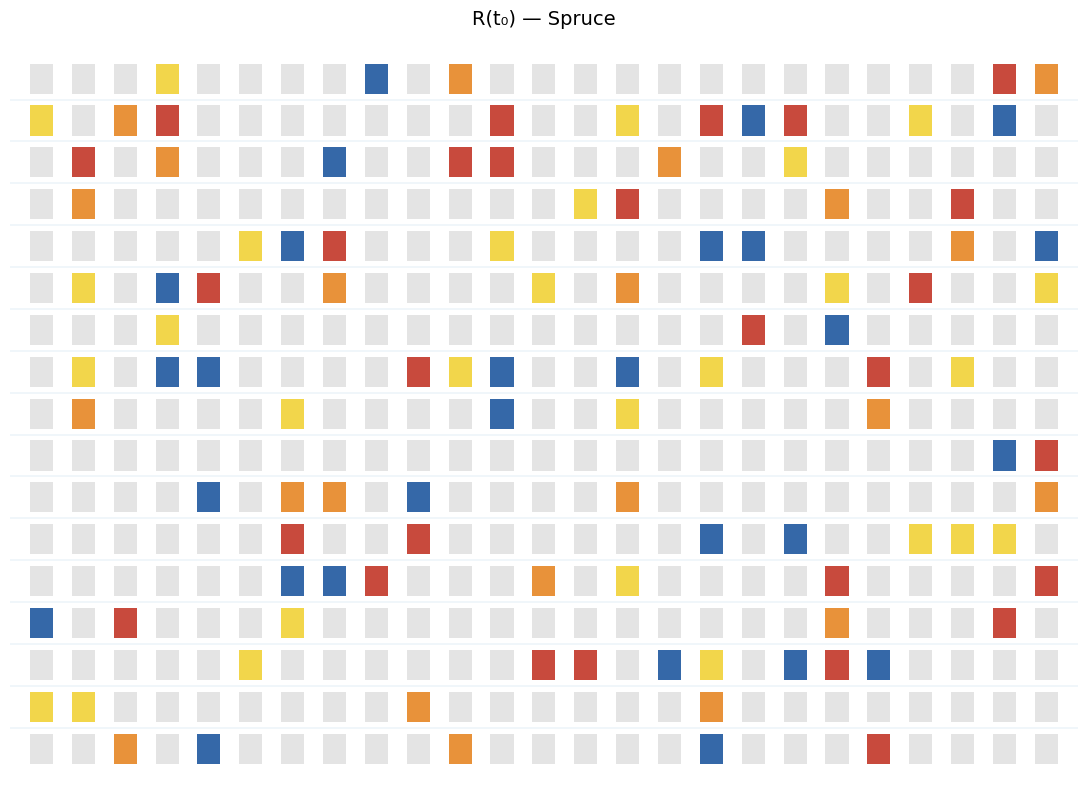

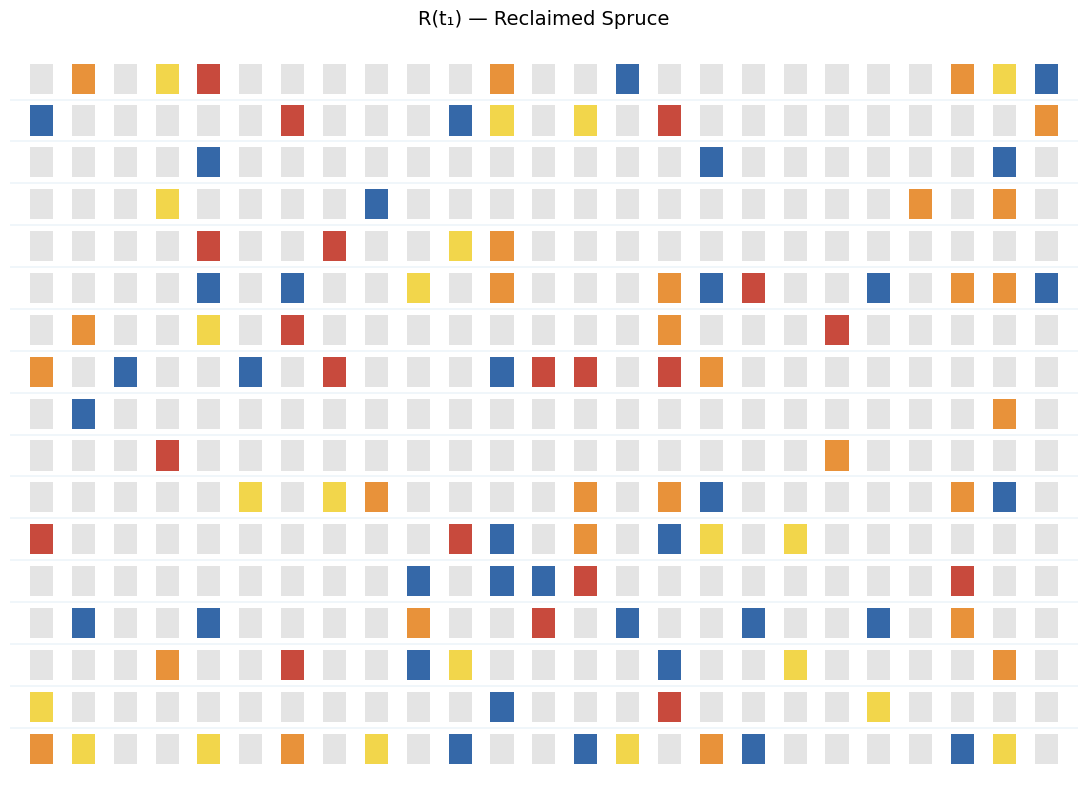

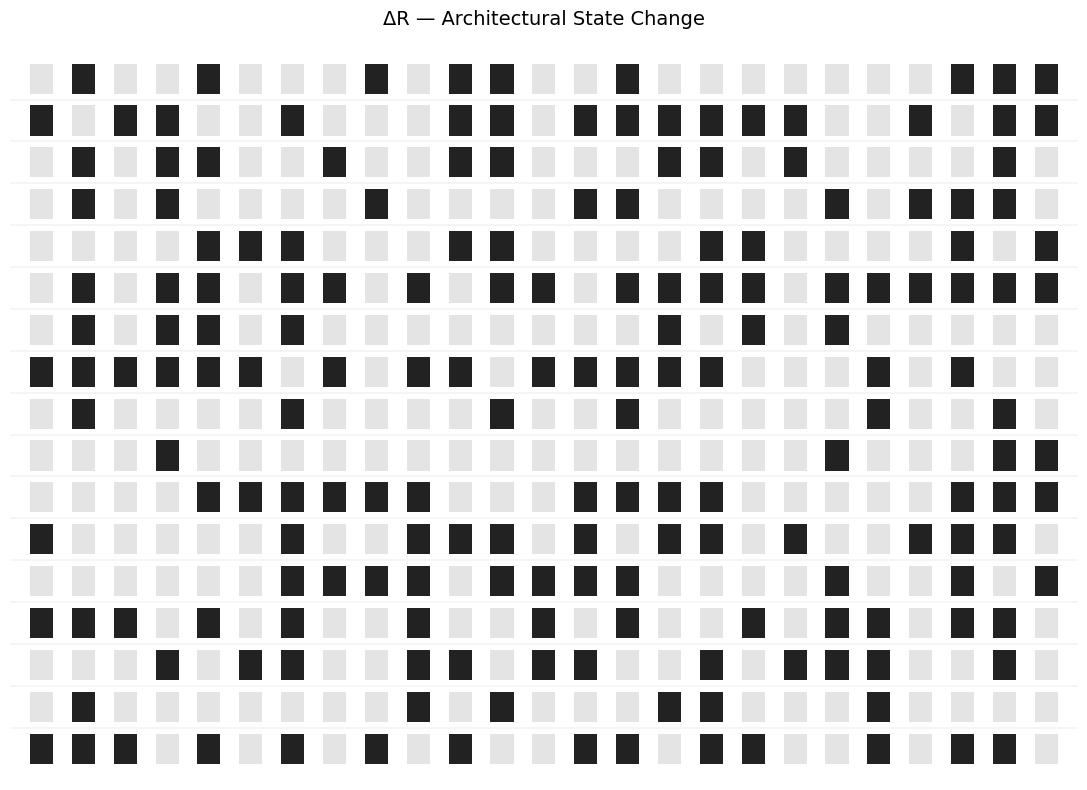

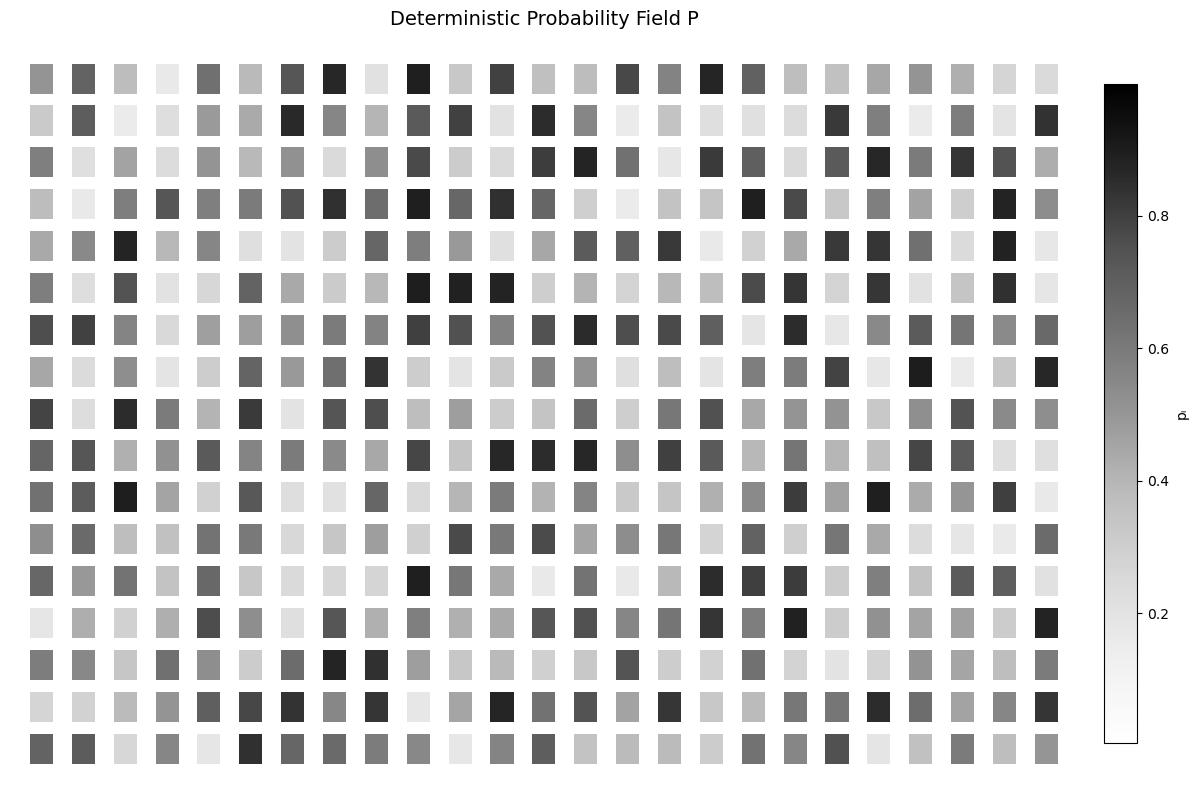

Reproducibility test passed: F(D, E) = R


In [1]:
"""
SELF-DESCRIBING ARCHITECTURE
Architectural Material Encoding Experiment
Version 0.1

Concept:
    BUILDING DATA
        -> CANONICAL REPRESENTATION
        -> CRYPTOGRAPHIC HASH
        -> DETERMINISTIC PROBABILITY FIELD
        -> ELEMENT SELECTION
        -> INFORMATION STATES
        -> ENTROPY
        -> ARCHITECTURAL PATTERN

Core reproducibility condition:

    F(building_data, entropy_target) = roof_state

for every execution.

The building data determines IDENTITY.
The entropy target determines DISTRIBUTION CHARACTERISTICS.

No uncontrolled randomness is used.
"""

from __future__ import annotations

import hashlib
import json
import math
import random

from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ============================================================
# 0. CONSTANTS
# ============================================================

N_ELEMENTS = 425
N_ACTIVE = 106

N_GROUPS = 17
ELEMENTS_PER_GROUP = 25

assert N_GROUPS * ELEMENTS_PER_GROUP == N_ELEMENTS

STATE_NAMES = {
    0: "yellow",
    1: "orange",
    2: "red",
    3: "blue",
}

STATE_COLORS = {
    0: "#F2D64B",  # yellow
    1: "#E8923A",  # orange
    2: "#C84A3D",  # red
    3: "#3568A8",  # blue
}

INACTIVE_COLOR = "#E4E4E4"
DIFFERENCE_COLOR = "#222222"


# ============================================================
# 1. DATA STRUCTURES
# ============================================================

@dataclass
class ArchitecturalElement:
    """
    One physical construction element.

    The element simultaneously has several informational dimensions:

        physical:
            index, x, y

        hierarchical:
            building -> roof -> group -> element

        probabilistic:
            probability

        informational:
            active, encoded_state, payload

        representational:
            color

    A physically simple timber member therefore has multiple
    latent informational dimensions.
    """

    index: int
    x: float
    y: float

    group: int

    active: bool
    probability: float

    encoded_state: Optional[int]
    color: str

    payload: Optional[Dict[str, Any]] = None


@dataclass
class RoofState:
    """
    Complete simultaneous state of the 425-element roof.

        R(t) = {e_1, e_2, ..., e_425}

    This object deliberately keeps the canonical representation
    and hash so hierarchical hashing can later be added cleanly.
    """

    building_data: Dict[str, Any]
    canonical_data: str

    hash_hex: str
    hash_binary: str

    entropy_target: float

    elements: List[ArchitecturalElement]

    state_probabilities: Tuple[float, float, float, float]


@dataclass
class RoofComparison:
    active_state_changes: int
    encoded_state_changes: int
    affected_elements: int
    affected_percentage: float
    hamming_distance: int


# ============================================================
# 2. CANONICAL BUILDING INFORMATION
# ============================================================

def canonicalize_building_data(building_data: Dict[str, Any]) -> str:
    """
    Produce deterministic canonical JSON.

    Properties:
        - dictionary key order does not matter
        - whitespace does not matter
        - identical semantic input produces identical output

    For this experiment the data types are intentionally simple.
    A production canonicalization specification would need more
    rigorous handling of floats, units, Unicode, dates, etc.
    """

    return json.dumps(
        building_data,
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=False,
    )


# ============================================================
# 3. CRYPTOGRAPHIC IDENTITY
# ============================================================

def calculate_building_hash(canonical_data: str) -> Tuple[str, str]:
    """
    SHA-256 becomes the digital identity of the architectural state.

    H = SHA256(C(D))

    Returns:
        hexadecimal representation
        exact 256-bit binary representation
    """

    digest = hashlib.sha256(
        canonical_data.encode("utf-8")
    ).digest()

    hash_hex = digest.hex()

    hash_binary = "".join(
        f"{byte:08b}" for byte in digest
    )

    assert len(hash_binary) == 256

    return hash_hex, hash_binary


# ============================================================
# 4. DETERMINISTIC PROBABILITY FIELD
# ============================================================

def create_probability_field(
    hash_hex: str,
    n: int = N_ELEMENTS,
) -> List[float]:
    """
    Generate the deterministic probability field

        P = {p_1, ..., p_425}

    with

        0 <= p_i < 1

    SHA-256 is converted into a large integer and used as the
    deterministic PRNG seed.

    Same hash -> same probability field.
    Different hash -> avalanche effect -> substantially new field.
    """

    seed = int(hash_hex, 16)

    rng = random.Random(seed)

    return [rng.random() for _ in range(n)]


# ============================================================
# 5. ACTIVE ELEMENT SELECTION
# ============================================================

def select_active_elements(
    probability_field: Sequence[float],
    n_active: int = N_ACTIVE,
) -> set[int]:
    """
    Deterministically select exactly 106 elements.

        A = argmin_106(P)

    Selection is therefore a ranking operation, not another
    stochastic operation.
    """

    ranked_indices = sorted(
        range(len(probability_field)),
        key=lambda i: (probability_field[i], i),
    )

    return set(ranked_indices[:n_active])


# ============================================================
# 6. ENTROPY DESIGN PARAMETER
# ============================================================

def state_probability_distribution(
    entropy_target: float,
) -> Tuple[float, float, float, float]:
    """
    Convert the architectural entropy control into a probability
    distribution over four states.

    entropy_target = 0:
        (1, 0, 0, 0)

        One state completely dominates.

    entropy_target = 1:
        (0.25, 0.25, 0.25, 0.25)

        Maximum theoretical heterogeneity.

    Intermediate values interpolate between these conditions.

    IMPORTANT:
    entropy_target is a DESIGN CONTROL, not the measured entropy.

    The realized Shannon entropy is calculated later from the
    actual 106-element state distribution.
    """

    if not 0.0 <= entropy_target <= 1.0:
        raise ValueError(
            "entropy_target must satisfy 0.0 <= entropy_target <= 1.0"
        )

    dominant = 1.0 - 0.75 * entropy_target
    remainder = (1.0 - dominant) / 3.0

    return (
        dominant,
        remainder,
        remainder,
        remainder,
    )


# ============================================================
# 7. DETERMINISTIC ELEMENT-LEVEL INFORMATION STREAM
# ============================================================

def deterministic_unit_value(
    building_hash_hex: str,
    element_index: int,
    namespace: str = "information-state",
) -> float:
    """
    Generate a deterministic value u_i in [0, 1).

    Instead of sharing the PRNG stream used for active selection,
    state assignment gets its own cryptographically derived stream.

        u_i = SHA256(H || namespace || i) / 2^256

    This separation is important:

        probability field -> WHERE information appears
        state stream       -> WHAT information state appears there

    The streams remain deterministic but conceptually independent.
    """

    message = (
        f"{building_hash_hex}|{namespace}|{element_index}"
    ).encode("utf-8")

    digest = hashlib.sha256(message).digest()

    integer = int.from_bytes(digest, byteorder="big")

    return integer / 2**256


def map_value_to_state(
    value: float,
    probabilities: Sequence[float],
) -> int:
    """
    Map deterministic u in [0,1) onto the categorical distribution.

    Example:

        probabilities =
        [0.25, 0.25, 0.25, 0.25]

        [0.00, 0.25) -> yellow
        [0.25, 0.50) -> orange
        [0.50, 0.75) -> red
        [0.75, 1.00) -> blue
    """

    cumulative = 0.0

    for state, probability in enumerate(probabilities):
        cumulative += probability

        if value < cumulative:
            return state

    # Protection against floating-point edge cases.
    return len(probabilities) - 1


# ============================================================
# 8. INFORMATION STATE ASSIGNMENT
# ============================================================

def assign_information_states(
    hash_hex: str,
    active_indices: set[int],
    entropy_target: float,
) -> Tuple[Dict[int, int], Tuple[float, float, float, float]]:
    """
    Assign each active element one of four informational states.

        0 = yellow
        1 = orange
        2 = red
        3 = blue

    Inactive elements carry no active state in Version 0.1.
    """

    probabilities = state_probability_distribution(
        entropy_target
    )

    states: Dict[int, int] = {}

    for index in sorted(active_indices):

        value = deterministic_unit_value(
            hash_hex,
            index,
        )

        states[index] = map_value_to_state(
            value,
            probabilities,
        )

    return states, probabilities


# ============================================================
# 9. ROOF GENERATION
# ============================================================

def create_roof_state(
    building_data: Dict[str, Any],
    entropy_target: float = 1.0,
) -> RoofState:
    """
    Main architectural function.

        R = F(D, E)

    D = building information
    E = entropy design parameter

    Spatial organization:

        17 groups
        25 elements per group

    giving exactly:

        17 * 25 = 425 elements
    """

    if building_data.get("elements") != N_ELEMENTS:
        raise ValueError(
            f"building_data['elements'] must equal {N_ELEMENTS}"
        )

    canonical_data = canonicalize_building_data(
        building_data
    )

    hash_hex, hash_binary = calculate_building_hash(
        canonical_data
    )

    probability_field = create_probability_field(
        hash_hex
    )

    active_indices = select_active_elements(
        probability_field
    )

    state_assignments, state_probabilities = (
        assign_information_states(
            hash_hex,
            active_indices,
            entropy_target,
        )
    )

    elements: List[ArchitecturalElement] = []

    for index in range(N_ELEMENTS):

        group = index // ELEMENTS_PER_GROUP

        # 25 vertical members across each group.
        column = index % ELEMENTS_PER_GROUP
        row = group

        active = index in active_indices

        encoded_state = (
            state_assignments[index]
            if active
            else None
        )

        color = (
            STATE_COLORS[encoded_state]
            if active
            else INACTIVE_COLOR
        )

        payload = None

        if active:
            payload = {
                "building_hash": hash_hex,
                "group": group + 1,
                "element": index + 1,
                "state": STATE_NAMES[encoded_state],
            }

        element = ArchitecturalElement(
            index=index,
            x=float(column),
            y=float(row),
            group=group + 1,
            active=active,
            probability=probability_field[index],
            encoded_state=encoded_state,
            color=color,
            payload=payload,
        )

        elements.append(element)

    assert len(elements) == N_ELEMENTS
    assert sum(e.active for e in elements) == N_ACTIVE

    return RoofState(
        building_data=dict(building_data),
        canonical_data=canonical_data,
        hash_hex=hash_hex,
        hash_binary=hash_binary,
        entropy_target=entropy_target,
        elements=elements,
        state_probabilities=state_probabilities,
    )


# ============================================================
# 10. INFORMATION CAPACITY
# ============================================================

def calculate_information_capacity() -> Dict[str, Any]:
    """
    Information capacity of a physical alphabet:

        I = N * log2(S)

    where:
        N = number of information-bearing elements
        S = number of possible states

    Current experiment:

        106 active elements
        4 possible states

        106 * log2(4)
        = 106 * 2
        = 212 bits

    Alternative whole-roof capacities are also calculated.
    """

    active_capacity = (
        N_ACTIVE * math.log2(4)
    )

    full_roof_capacities = {}

    for states in (2, 4, 8, 16):
        full_roof_capacities[states] = (
            N_ELEMENTS * math.log2(states)
        )

    return {
        "active_4_state_bits": active_capacity,
        "full_roof": full_roof_capacities,
    }


# ============================================================
# 11. SHANNON ENTROPY
# ============================================================

def calculate_entropy(
    roof: RoofState,
) -> Dict[str, Any]:
    """
    Shannon entropy:

        H(X) = -sum p(x) log2 p(x)

    Calculated from the OBSERVED distribution of the
    106 active architectural elements.

    Maximum entropy for four states:

        H_max = log2(4) = 2 bits/state

    Normalized:

        H_normalized = H / H_max
    """

    counts = {
        state: 0
        for state in STATE_NAMES
    }

    for element in roof.elements:

        if element.active:
            counts[element.encoded_state] += 1

    total = sum(counts.values())

    probabilities = {
        state: count / total
        for state, count in counts.items()
    }

    entropy = 0.0

    for probability in probabilities.values():

        if probability > 0:
            entropy -= (
                probability
                * math.log2(probability)
            )

    maximum_entropy = math.log2(
        len(STATE_NAMES)
    )

    normalized_entropy = (
        entropy / maximum_entropy
        if maximum_entropy > 0
        else 0.0
    )

    return {
        "counts": counts,
        "probabilities": probabilities,
        "entropy": entropy,
        "maximum_entropy": maximum_entropy,
        "normalized_entropy": normalized_entropy,
    }


# ============================================================
# 12. TEMPORAL REPRESENTATION
# ============================================================

def element_symbol(
    element: ArchitecturalElement,
) -> int:
    """
    Encode an element as one discrete architectural symbol:

        0 = inactive
        1 = yellow
        2 = orange
        3 = red
        4 = blue

    This makes R(t) comparable as a 425-symbol sequence.
    """

    if not element.active:
        return 0

    return element.encoded_state + 1


def compare_roof_states(
    roof_a: RoofState,
    roof_b: RoofState,
) -> RoofComparison:
    """
    Compare two architectural moments.

        R(t0)
        R(t1)

    Hamming distance is defined here as the number of positions
    in the 425-element architectural symbol sequence that differ.

        d_H(R0, R1) =
            |{i : symbol(R0_i) != symbol(R1_i)}|

    This is an ELEMENT-LEVEL Hamming distance, rather than a
    bit-level Hamming distance.
    """

    if len(roof_a.elements) != len(roof_b.elements):
        raise ValueError(
            "Roof states must contain the same number of elements."
        )

    active_state_changes = 0
    encoded_state_changes = 0
    affected_elements = 0
    hamming_distance = 0

    for a, b in zip(
        roof_a.elements,
        roof_b.elements,
    ):

        active_changed = (
            a.active != b.active
        )

        symbol_changed = (
            element_symbol(a)
            != element_symbol(b)
        )

        if active_changed:
            active_state_changes += 1

        if symbol_changed:
            encoded_state_changes += 1
            hamming_distance += 1

        if active_changed or symbol_changed:
            affected_elements += 1

    affected_percentage = (
        100.0
        * affected_elements
        / N_ELEMENTS
    )

    return RoofComparison(
        active_state_changes=active_state_changes,
        encoded_state_changes=encoded_state_changes,
        affected_elements=affected_elements,
        affected_percentage=affected_percentage,
        hamming_distance=hamming_distance,
    )


# ============================================================
# 13. ARCHITECTURAL VISUALIZATION
# ============================================================

def visualize_roof(
    roof: RoofState,
    title: str,
) -> None:
    """
    Architectural diagram rather than statistical chart.

    Each element is drawn as a vertical rectangular timber member.
    """

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )

    member_width = 0.55
    member_height = 0.72

    for element in roof.elements:

        x = element.x - member_width / 2
        y = element.y - member_height / 2

        rectangle = Rectangle(
            (x, y),
            member_width,
            member_height,
            facecolor=element.color,
            edgecolor="none",
        )

        ax.add_patch(rectangle)

    # Group boundaries.
    for boundary in range(1, N_GROUPS):
        ax.axhline(
            boundary - 0.5,
            linewidth=0.35,
            alpha=0.25,
        )

    ax.set_xlim(
        -0.75,
        ELEMENTS_PER_GROUP - 0.25,
    )

    ax.set_ylim(
        N_GROUPS - 0.25,
        -0.75,
    )

    ax.set_aspect("equal")

    ax.set_title(
        title,
        fontsize=14,
        pad=16,
    )

    ax.axis("off")

    plt.tight_layout()
    plt.show()


def visualize_difference(
    roof_a: RoofState,
    roof_b: RoofState,
    title: str = "ΔR — Architectural State Change",
) -> None:
    """
    Difference map.

    Dark members indicate elements whose complete architectural
    symbol changed between R(t0) and R(t1).

    Pale members remained identical.
    """

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )

    member_width = 0.55
    member_height = 0.72

    for a, b in zip(
        roof_a.elements,
        roof_b.elements,
    ):

        changed = (
            element_symbol(a)
            != element_symbol(b)
        )

        color = (
            DIFFERENCE_COLOR
            if changed
            else INACTIVE_COLOR
        )

        rectangle = Rectangle(
            (
                a.x - member_width / 2,
                a.y - member_height / 2,
            ),
            member_width,
            member_height,
            facecolor=color,
            edgecolor="none",
        )

        ax.add_patch(rectangle)

    for boundary in range(1, N_GROUPS):
        ax.axhline(
            boundary - 0.5,
            linewidth=0.35,
            alpha=0.25,
        )

    ax.set_xlim(
        -0.75,
        ELEMENTS_PER_GROUP - 0.25,
    )

    ax.set_ylim(
        N_GROUPS - 0.25,
        -0.75,
    )

    ax.set_aspect("equal")
    ax.set_title(title, fontsize=14, pad=16)
    ax.axis("off")

    plt.tight_layout()
    plt.show()


def visualize_probability_field(
    roof: RoofState,
) -> None:
    """
    Optional view of the latent deterministic probability field.

    This shows the numerical substrate from which the active
    architectural elements emerge.
    """

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )

    member_width = 0.55
    member_height = 0.72

    probabilities = [
        element.probability
        for element in roof.elements
    ]

    cmap = plt.get_cmap("Greys")

    for element in roof.elements:

        color = cmap(
            0.15 + 0.75 * element.probability
        )

        rectangle = Rectangle(
            (
                element.x - member_width / 2,
                element.y - member_height / 2,
            ),
            member_width,
            member_height,
            facecolor=color,
            edgecolor="none",
        )

        ax.add_patch(rectangle)

    ax.set_xlim(
        -0.75,
        ELEMENTS_PER_GROUP - 0.25,
    )

    ax.set_ylim(
        N_GROUPS - 0.25,
        -0.75,
    )

    ax.set_aspect("equal")

    ax.set_title(
        "Deterministic Probability Field P",
        fontsize=14,
        pad=16,
    )

    ax.axis("off")

    scalar_map = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(
            min(probabilities),
            max(probabilities),
        ),
    )

    scalar_map.set_array([])

    fig.colorbar(
        scalar_map,
        ax=ax,
        fraction=0.025,
        pad=0.02,
        label="pᵢ",
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 14. ANALYTICAL REPORT
# ============================================================

def print_report(
    roof: RoofState,
    comparison: Optional[RoofComparison] = None,
) -> None:

    entropy_data = calculate_entropy(
        roof
    )

    capacity = calculate_information_capacity()

    active_ratio = (
        N_ACTIVE / N_ELEMENTS
    )

    print()
    print("=" * 64)
    print("SELF-DESCRIBING ARCHITECTURE")
    print("Architectural Material Encoding Experiment")
    print("=" * 64)

    print(f"Elements:               {N_ELEMENTS}")
    print(f"Groups:                 {N_GROUPS} × {ELEMENTS_PER_GROUP}")
    print(f"Active elements:        {N_ACTIVE}")
    print(
        f"Active ratio:           "
        f"{N_ACTIVE}/{N_ELEMENTS} "
        f"= {active_ratio:.4f} "
        f"({active_ratio * 100:.2f}%)"
    )

    print()
    print("ARCHITECTURAL IDENTITY")
    print(f"SHA-256: {roof.hash_hex}")
    print(f"Binary:  {roof.hash_binary}")

    print()
    print("INFORMATION CAPACITY")

    print(
        "Active elements / 4 states: "
        f"{capacity['active_4_state_bits']:.0f} bits"
    )

    for states, bits in capacity["full_roof"].items():

        bits_per_element = math.log2(states)

        print(
            f"425 elements / {states:2d} states: "
            f"{bits:.0f} bits "
            f"({bits_per_element:.0f} bits/element)"
        )

    print()
    print("STATE DISTRIBUTION")

    for state in range(4):

        name = STATE_NAMES[state].capitalize()

        count = entropy_data["counts"][state]
        probability = entropy_data[
            "probabilities"
        ][state]

        print(
            f"{name:<8}: "
            f"{count:3d} "
            f"({probability:.4f})"
        )

    print()
    print(
        f"Entropy target:         "
        f"{roof.entropy_target:.4f}"
    )

    print(
        f"Shannon entropy:        "
        f"{entropy_data['entropy']:.4f} bits/state"
    )

    print(
        f"Maximum entropy:        "
        f"{entropy_data['maximum_entropy']:.4f} bits/state"
    )

    print(
        f"Normalized entropy:     "
        f"{entropy_data['normalized_entropy']:.4f}"
    )

    if comparison is not None:

        print()
        print("TEMPORAL COMPARISON")

        print(
            f"Active/inactive changes: "
            f"{comparison.active_state_changes}"
        )

        print(
            f"Encoded state changes:   "
            f"{comparison.encoded_state_changes}"
        )

        print(
            f"Affected elements:       "
            f"{comparison.affected_elements}"
        )

        print(
            f"Roof affected:           "
            f"{comparison.affected_percentage:.2f}%"
        )

        print(
            f"Hamming distance:        "
            f"{comparison.hamming_distance}/{N_ELEMENTS}"
        )

    print("=" * 64)
    print()


# ============================================================
# 15. EXPERIMENT
# ============================================================

def main() -> None:

    # --------------------------------------------------------
    # Architectural state t0
    # --------------------------------------------------------

    building_data_t0 = {
        "project": "AlgoTecture House 01",
        "assembly": "Roof",
        "material": "Spruce",
        "elements": 425,
        "location": "Zurich",
        "construction_year": 2027,
        "architect": "AlgoTecture",
    }

    entropy_target = 1.0

    roof_t0 = create_roof_state(
        building_data_t0,
        entropy_target=entropy_target,
    )

    # --------------------------------------------------------
    # Architectural state t1
    #
    # One meaningful architectural fact changes.
    # --------------------------------------------------------

    building_data_t1 = dict(
        building_data_t0
    )

    building_data_t1["material"] = (
        "Reclaimed Spruce"
    )

    roof_t1 = create_roof_state(
        building_data_t1,
        entropy_target=entropy_target,
    )

    # --------------------------------------------------------
    # Temporal recording
    # --------------------------------------------------------

    comparison = compare_roof_states(
        roof_t0,
        roof_t1,
    )

    # --------------------------------------------------------
    # Analytical output
    # --------------------------------------------------------

    print("\nR(t0)")
    print_report(
        roof_t0,
        comparison=comparison,
    )

    print("R(t1)")
    print_report(
        roof_t1,
    )

    # --------------------------------------------------------
    # Visualization
    # --------------------------------------------------------

    visualize_roof(
        roof_t0,
        "R(t₀) — Spruce",
    )

    visualize_roof(
        roof_t1,
        "R(t₁) — Reclaimed Spruce",
    )

    visualize_difference(
        roof_t0,
        roof_t1,
    )

    visualize_probability_field(
        roof_t0,
    )

    # --------------------------------------------------------
    # REPRODUCIBILITY TEST
    # --------------------------------------------------------

    roof_t0_again = create_roof_state(
        building_data_t0,
        entropy_target=entropy_target,
    )

    assert (
        roof_t0.hash_hex
        == roof_t0_again.hash_hex
    )

    assert [
        (
            e.active,
            e.encoded_state,
            e.probability,
        )
        for e in roof_t0.elements
    ] == [
        (
            e.active,
            e.encoded_state,
            e.probability,
        )
        for e in roof_t0_again.elements
    ]

    print(
        "Reproducibility test passed:"
        " F(D, E) = R"
    )


# ============================================================
# 16. FUTURE RESEARCH DIRECTIONS
# ============================================================

# TODO v0.2:
# Introduce element-level hashes:
#
#     H_element = SHA256(
#         building_hash
#         || group
#         || element_index
#         || payload
#     )
#
# This would make individual physical members independently
# identifiable.


# TODO v0.3:
# Introduce hierarchical hashes:
#
#     BUILDING HASH
#         -> ROOF HASH
#             -> GROUP HASH
#                 -> ELEMENT HASH
#
# Eventually this could become a Merkle tree.


# TODO:
# Reed-Solomon / erasure coding.
#
# Information should survive the loss of physical members.
# The central research variable becomes:
#
#     recoverability = f(surviving matter)


# TODO:
# Distributed redundancy.
#
# Avoid storing one indispensable fragment in one indispensable
# physical location.


# TODO:
# Recovery from missing physical elements.
#
# Simulate destruction:
#
#     R -> R'
#
# and measure the fraction of the original informational state
# that remains reconstructable.


# TODO:
# Computer-vision decoding.
#
# Translate physical color / geometry / orientation / texture
# back into digital states through scanning.


# TODO:
# IFC GUID integration.
#
# Bind encoded physical elements to formal BIM entities without
# making IFC the primary information architecture.


# TODO:
# Material passports and provenance.
#
# Element payloads could eventually describe origin, manufacture,
# assembly, maintenance, reuse, and transformation.


# TODO:
# Append-only architectural history.
#
# Instead of overwriting:
#
#     R(t0) -> R(t1)
#
# preserve:
#
#     R(t0), R(t1), R(t2), ...
#
# Architecture becomes a temporal information record.


# TODO:
# Physical fabrication constraints.
#
# Encoding must eventually respect:
#
#     structural constraints
#     fabrication tolerances
#     assembly logic
#     visibility
#     weathering
#     replacement
#     material behavior


# TODO:
# Study the fundamental survivability question:
#
# "How little of a building must remain before the surviving
#  matter can no longer tell us what building it belonged to?"


if __name__ == "__main__":
    main()

SELF-DESCRIBING ARCHITECTURE
Architectural Material Encoding Experiment (v0.1)
Elements:                  425
Active elements:           106
Active ratio:              0.2494 (24.94%)
SHA-256 Digest:            c3c2a087ff7fc08efefb1520ff66771a5aaf10f697d585580a32f10bb2d634f1
Active info capacity:      212.0 bits
-----------------------------------------------------------------
State Distribution R(t0):
  State 0 (Yellow):   23 elements (21.70%)
  State 1 (Orange):   35 elements (33.02%)
  State 2 (Red):      26 elements (24.53%)
  State 3 (Blue):     22 elements (20.75%)
-----------------------------------------------------------------
Shannon Entropy H(X):      1.9743 bits
Maximum Entropy H_max:     2.0000 bits
Normalized Entropy:        0.9871
-----------------------------------------------------------------
Temporal Comparison R(t0) vs R(t1):
  Active state changes:    166
  Encoded state changes:   183
  Roof area affected:      43.06%
  Hash Hamming distance:   116 bits (out of 25

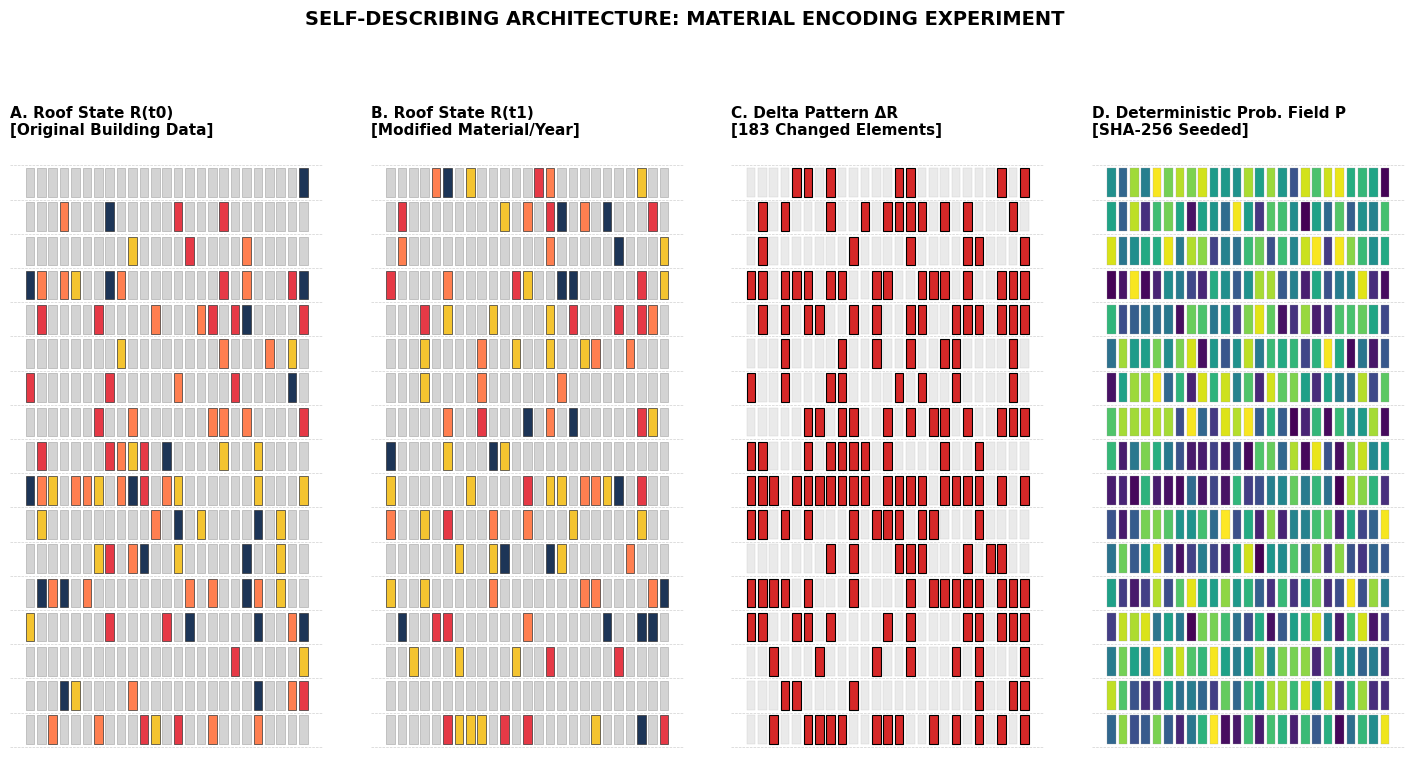

In [2]:
"""
Self-Describing Architecture / Architectural Material Encoding
Version 0.1 - Experimental Prototype

Translates building identity into a deterministic, spatial, material-encoded 
information system across a 425-element roof structure.
"""

from dataclasses import dataclass, field
import hashlib
import json
import math
from typing import Dict, List, Tuple, Optional
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np


# =============================================================================
# DATA STRUCTURES
# =============================================================================

@dataclass
class ArchitecturalElement:
    """Represents a single physical construction element in the roof ensemble."""
    index: int
    x: float
    y: float
    group: int
    active: bool = False
    probability: float = 0.0
    encoded_state: Optional[int] = None  # None (inactive), 0, 1, 2, 3
    color: str = "#E0E0E0"  # Neutral light gray by default
    payload: Optional[Dict] = field(default_factory=dict)


@dataclass
class RoofState:
    """Represents the complete spatial informational state of the roof system."""
    building_data: Dict
    canonical_representation: str
    hash_hex: str
    hash_bin: str
    elements: List[ArchitecturalElement]
    entropy_target: float
    shannon_entropy: float
    normalized_entropy: float
    active_capacity_bits: float
    state_frequencies: Dict[int, int]
    state_probabilities: Dict[int, float]


# =============================================================================
# CORE ENCODING ENGINE
# =============================================================================

COLOR_MAP = {
    None: "#D3D3D3",  # Inactive: neutral light gray
    0: "#F4C430",     # State 0: Yellow
    1: "#FF7F50",     # State 1: Orange
    2: "#E63946",     # State 2: Red
    3: "#1D3557",     # State 3: Blue
}

STATE_NAMES = {0: "Yellow", 1: "Orange", 2: "Red", 3: "Blue"}


def canonicalize_building_data(data: Dict) -> str:
    """
    Produces a deterministic JSON string.
    Ensures key ordering and formatting variations do not alter the identity hash.
    """
    return json.dumps(data, sort_keys=True, separators=(',', ':'))


def calculate_building_hash(canonical_data: str) -> Tuple[str, str]:
    """Calculates SHA-256 hash, returning hex and binary string representations."""
    digest = hashlib.sha256(canonical_data.encode('utf-8')).digest()
    hash_hex = digest.hex()
    hash_bin = "".join(f"{byte:08b}" for byte in digest)
    return hash_hex, hash_bin


def derive_hash_float(seed_bytes: bytes, tag: str, index: int) -> float:
    """
    Generates a deterministic float in [0.0, 1.0) using HMAC-like SHA-256 derivation.
    Ensures zero reliance on uncontrolled platform PRNGs.
    """
    payload = seed_bytes + tag.encode('utf-8') + index.to_bytes(4, byteorder='big')
    h = hashlib.sha256(payload).digest()
    uint32_val = int.from_bytes(h[:4], byteorder='big')
    return uint32_val / (2**32)


def create_probability_field(hash_hex: str, num_elements: int = 425) -> List[float]:
    """Generates a deterministic probability field P = {p_1, ..., p_425}."""
    seed_bytes = bytes.fromhex(hash_hex)
    return [derive_hash_float(seed_bytes, "prob", i) for i in range(num_elements)]


def select_active_elements(probabilities: List[float], target_count: int = 106) -> List[int]:
    """
    Selects active elements deterministically using argmin_K(P).
    The K lowest probability values become active information carriers.
    """
    indexed_p = list(enumerate(probabilities))
    indexed_p.sort(key=lambda item: item[1])
    return [idx for idx, p in indexed_p[:target_count]]


def assign_information_states(
    hash_hex: str, 
    active_indices: List[int], 
    entropy_target: float
) -> Dict[int, int]:
    """
    Assigns active elements to states {0, 1, 2, 3} deterministically.
    
    The entropy_target (0.0 <= E <= 1.0) shapes the CDF boundaries:
    - E = 1.0 -> Equiprobable uniform distribution [0.25, 0.25, 0.25, 0.25] (Max Entropy)
    - E = 0.0 -> State 0 dominates [1.0, 0.0, 0.0, 0.0] (Zero Entropy)
    """
    seed_bytes = bytes.fromhex(hash_hex)
    
    # Calculate state distribution weights based on target entropy E
    w0 = 0.25 + 0.75 * (1.0 - entropy_target)
    w_other = 0.25 * entropy_target
    weights = [w0, w_other, w_other, w_other]
    
    # Calculate Cumulative Density Function (CDF) boundaries
    cdf = np.cumsum(weights)
    
    state_assignments = {}
    for idx in active_indices:
        u = derive_hash_float(seed_bytes, "state", idx)
        if u < cdf[0]:
            state = 0
        elif u < cdf[1]:
            state = 1
        elif u < cdf[2]:
            state = 2
        else:
            state = 3
        state_assignments[idx] = state
        
    return state_assignments


def calculate_entropy(state_assignments: Dict[int, int]) -> Tuple[float, float, Dict[int, int], Dict[int, float]]:
    """Calculates Shannon Entropy H(X) and Normalized Entropy H_norm."""
    counts = {s: 0 for s in range(4)}
    for s in state_assignments.values():
        counts[s] += 1
        
    total = len(state_assignments)
    probs = {s: counts[s] / total if total > 0 else 0.0 for s in range(4)}
    
    shannon_h = 0.0
    for p in probs.values():
        if p > 0:
            shannon_h -= p * math.log2(p)
            
    h_max = math.log2(4)  # 2.0 bits
    h_normalized = shannon_h / h_max if h_max > 0 else 0.0
    
    return shannon_h, h_normalized, counts, probs


def calculate_information_capacity(num_elements: int, active_count: int) -> Dict[str, float]:
    """Calculates theoretical information capacity across different state counts."""
    return {
        "active_106_elements_4_states": active_count * math.log2(4),  # 212 bits
        "all_425_elements_2_states": num_elements * math.log2(2),    # 425 bits
        "all_425_elements_4_states": num_elements * math.log2(4),    # 850 bits
        "all_425_elements_8_states": num_elements * math.log2(8),    # 1275 bits
        "all_425_elements_16_states": num_elements * math.log2(16),  # 1700 bits
    }


def create_roof_state(building_data: Dict, entropy_target: float = 1.0) -> RoofState:
    """Constructs a complete, deterministic RoofState from data and entropy parameters."""
    canonical = canonicalize_building_data(building_data)
    h_hex, h_bin = calculate_building_hash(canonical)
    
    num_elements = 425
    active_target = 106
    groups_count = 17
    elements_per_group = 25
    
    prob_field = create_probability_field(h_hex, num_elements)
    active_indices = set(select_active_elements(prob_field, active_target))
    state_assignments = assign_information_states(h_hex, list(active_indices), entropy_target)
    shannon_h, h_norm, counts, probs = calculate_entropy(state_assignments)
    
    elements = []
    for i in range(num_elements):
        group_id = (i // elements_per_group) + 1  # Groups 1 to 17
        elem_in_group = i % elements_per_group     # 0 to 24
        
        # Spatial placement grid: 25 rafters wide (X), 17 bays deep (Y)
        x_pos = float(elem_in_group)
        y_pos = float(17 - group_id)
        
        is_active = i in active_indices
        enc_state = state_assignments.get(i, None)
        color = COLOR_MAP[enc_state]
        
        elem = ArchitecturalElement(
            index=i,
            x=x_pos,
            y=y_pos,
            group=group_id,
            active=is_active,
            probability=prob_field[i],
            encoded_state=enc_state,
            color=color,
            payload={"group_member_index": elem_in_group}
        )
        elements.append(elem)
        
    capacity = active_target * math.log2(4)
    
    return RoofState(
        building_data=building_data,
        canonical_representation=canonical,
        hash_hex=h_hex,
        hash_bin=h_bin,
        elements=elements,
        entropy_target=entropy_target,
        shannon_entropy=shannon_h,
        normalized_entropy=h_norm,
        active_capacity_bits=capacity,
        state_frequencies=counts,
        state_probabilities=probs
    )


def compare_roof_states(r0: RoofState, r1: RoofState) -> Dict:
    """Compares two roof states across time t0 and t1 to evaluate encoding changes."""
    active_changes = 0
    state_changes = 0
    
    for e0, e1 in zip(r0.elements, r1.elements):
        if e0.active != e1.active:
            active_changes += 1
        if e0.encoded_state != e1.encoded_state:
            state_changes += 1
            
    pct_affected = (state_changes / len(r0.elements)) * 100.0
    
    # Calculate Hamming distance between binary hash representations
    hamming_dist = sum(b0 != b1 for b0, b1 in zip(r0.hash_bin, r1.hash_bin))
    
    return {
        "active_state_changes": active_changes,
        "encoded_state_changes": state_changes,
        "percentage_roof_affected": pct_affected,
        "hash_hamming_distance": hamming_dist
    }


# =============================================================================
# VISUALIZATION SYSTEM
# =============================================================================

def render_roof_panel(ax, roof: RoofState, title: str):
    """Renders a single roof state as vertical timber rafters/slats."""
    ax.set_facecolor('#F8F9FA')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10, loc='left')
    
    # Draw 425 architectural slat elements
    for elem in roof.elements:
        # Render as vertical rectangular timber members
        rect = patches.Rectangle(
            (elem.x * 0.4 + 0.05, elem.y * 1.2 + 0.1), 
            0.3, 1.0, 
            linewidth=0.5, 
            edgecolor='#B0B0B0' if not elem.active else '#333333',
            facecolor=elem.color,
            zorder=3 if elem.active else 2
        )
        ax.add_patch(rect)
        
    # Draw group boundaries (17 rows of 25 elements)
    for g in range(18):
        ax.axhline(y=g * 1.2, color='#D0D0D0', linestyle='--', linewidth=0.5, zorder=1)
        
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 21.0)
    ax.set_aspect('equal')
    ax.axis('off')


def render_difference_panel(ax, r0: RoofState, r1: RoofState, title: str):
    """Renders delta pattern highlighting modified physical elements."""
    ax.set_facecolor('#F8F9FA')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10, loc='left')
    
    for e0, e1 in zip(r0.elements, r1.elements):
        changed = (e0.encoded_state != e1.encoded_state)
        color = '#D62828' if changed else '#EAEAEA'
        edge = '#000000' if changed else '#D0D0D0'
        
        rect = patches.Rectangle(
            (e0.x * 0.4 + 0.05, e0.y * 1.2 + 0.1), 
            0.3, 1.0, 
            linewidth=0.8 if changed else 0.3, 
            edgecolor=edge,
            facecolor=color,
            zorder=4 if changed else 2
        )
        ax.add_patch(rect)
        
    for g in range(18):
        ax.axhline(y=g * 1.2, color='#D0D0D0', linestyle='--', linewidth=0.5, zorder=1)
        
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 21.0)
    ax.set_aspect('equal')
    ax.axis('off')


def render_probability_panel(ax, roof: RoofState, title: str):
    """Renders the continuous probability field across the 425 elements."""
    ax.set_facecolor('#F8F9FA')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10, loc='left')
    
    probs = [e.probability for e in roof.elements]
    cmap = plt.cm.viridis
    
    for elem in roof.elements:
        col = cmap(elem.probability)
        rect = patches.Rectangle(
            (elem.x * 0.4 + 0.05, elem.y * 1.2 + 0.1), 
            0.3, 1.0, 
            linewidth=0.2, 
            edgecolor='#A0A0A0',
            facecolor=col,
            zorder=2
        )
        ax.add_patch(rect)
        
    for g in range(18):
        ax.axhline(y=g * 1.2, color='#D0D0D0', linestyle='--', linewidth=0.5, zorder=1)
        
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 21.0)
    ax.set_aspect('equal')
    ax.axis('off')


def visualize_experiment(r0: RoofState, r1: RoofState, diff: Dict):
    """Creates the 4-panel architectural diagram of the computational experiment."""
    fig, axes = plt.subplots(1, 4, figsize=(18, 9), facecolor='white')
    
    render_roof_panel(axes[0], r0, "A. Roof State R(t0)\n[Original Building Data]")
    render_roof_panel(axes[1], r1, "B. Roof State R(t1)\n[Modified Material/Year]")
    render_difference_panel(axes[2], r0, r1, f"C. Delta Pattern ΔR\n[{diff['encoded_state_changes']} Changed Elements]")
    render_probability_panel(axes[3], r0, "D. Deterministic Prob. Field P\n[SHA-256 Seeded]")
    
    plt.subplots_adjust(wspace=0.15, top=0.88, bottom=0.05)
    fig.suptitle("SELF-DESCRIBING ARCHITECTURE: MATERIAL ENCODING EXPERIMENT", 
                 fontsize=14, fontweight='bold', y=0.96)
    
    plt.show()


# =============================================================================
# MAIN EXECUTION & REPORTING
# =============================================================================

def print_analytical_report(r0: RoofState, r1: RoofState, diff: Dict):
    """Prints the analytical report summarizing metrics and theoretical capacities."""
    capacities = calculate_information_capacity(425, 106)
    
    print("=" * 65)
    print("SELF-DESCRIBING ARCHITECTURE")
    print("Architectural Material Encoding Experiment (v0.1)")
    print("=" * 65)
    print(f"Elements:                  {len(r0.elements)}")
    print(f"Active elements:           {sum(1 for e in r0.elements if e.active)}")
    print(f"Active ratio:              {sum(1 for e in r0.elements if e.active)/len(r0.elements):.4f} ({sum(1 for e in r0.elements if e.active)/len(r0.elements)*100:.2f}%)")
    print(f"SHA-256 Digest:            {r0.hash_hex}")
    print(f"Active info capacity:      {r0.active_capacity_bits:.1f} bits")
    print("-" * 65)
    print("State Distribution R(t0):")
    for s_idx, name in STATE_NAMES.items():
        freq = r0.state_frequencies[s_idx]
        prob = r0.state_probabilities[s_idx]
        print(f"  State {s_idx} ({name}):".ljust(22) + f"{freq} elements ({prob*100:.2f}%)")
    print("-" * 65)
    print(f"Shannon Entropy H(X):      {r0.shannon_entropy:.4f} bits")
    print(f"Maximum Entropy H_max:     2.0000 bits")
    print(f"Normalized Entropy:        {r0.normalized_entropy:.4f}")
    print("-" * 65)
    print("Temporal Comparison R(t0) vs R(t1):")
    print(f"  Active state changes:    {diff['active_state_changes']}")
    print(f"  Encoded state changes:   {diff['encoded_state_changes']}")
    print(f"  Roof area affected:      {diff['percentage_roof_affected']:.2f}%")
    print(f"  Hash Hamming distance:   {diff['hash_hamming_distance']} bits (out of 256)")
    print("-" * 65)
    print("Theoretical Material Capacities (All 425 Elements):")
    print(f"  2-state encoding:        {capacities['all_425_elements_2_states']:.0f} bits")
    print(f"  4-state encoding:        {capacities['all_425_elements_4_states']:.0f} bits")
    print(f"  8-state encoding:        {capacities['all_425_elements_8_states']:.0f} bits")
    print(f"  16-state encoding:       {capacities['all_425_elements_16_states']:.0f} bits")
    print("=" * 65)


def run_experiment():
    # 1. State R(t0): Baseline Building Data
    building_data_t0 = {
        "project": "AlgoTecture House 01",
        "assembly": "Roof",
        "material": "Spruce",
        "elements": 425,
        "location": "Zurich",
        "construction_year": 2027,
        "architect": "AlgoTecture"
    }
    
    # 2. State R(t1): Modified Data (Temporal progression / Material update)
    building_data_t1 = {
        "project": "AlgoTecture House 01",
        "assembly": "Roof",
        "material": "Reclaimed Spruce",
        "elements": 425,
        "location": "Zurich",
        "construction_year": 2028,
        "architect": "AlgoTecture"
    }

    # Generate deterministic states (Entropy target E = 1.0 for high diversity)
    r0 = create_roof_state(building_data_t0, entropy_target=1.0)
    r1 = create_roof_state(building_data_t1, entropy_target=1.0)
    
    # Compare states across time
    diff = compare_roof_states(r0, r1)
    
    # Output analytical report & render visualization
    print_analytical_report(r0, r1, diff)
    visualize_experiment(r0, r1, diff)


if __name__ == "__main__":
    run_experiment()


# =============================================================================
# FUTURE EXTENSIONS & RESEARCH ROADMAP (TODO)
# =============================================================================

# TODO: Implement Reed-Solomon / Erasure Coding across active elements to allow
#       data recovery even if up to 50% of the physical roof elements are destroyed.
#
# TODO: Construct a hierarchical Merkle Tree across the 17 element groups (G_1 .. G_17),
#       enabling local element identity verification without scanning the entire roof.
#
# TODO: Map Industry Foundation Classes (IFC) GUIDs and Material Passports directly
#       into the active element payload bits.
#
# TODO: Implement a Computer Vision decoding pipeline (OpenCV) to extract material
#       color states from drone imagery and automatically reconstruct building_data.
#
# TODO: Integrate append-only physical lifecycle logging where physical maintenance 
#       events alter local element state color markers without invalidating root hash.

SELF-DESCRIBING ARCHITECTURE
Architectural Material Encoding Experiment

Architectural state:
--------------------
Elements: 425
Groups: 17
Elements/group: 25

Cryptographic identity R(t0):
-----------------------
SHA-256: cc2671f80d7afb1ffb3a7f3efe73ab4266451a80075e4ec1d01ac5b98156d493
Binary Prefix: 11001100001001100111000111111000...

Information:
------------
Global information measure I(D): 0.578944
Method used: Normalized Byte-Level Shannon Entropy of Canonical JSON

Emergent architecture R(t0):
----------------------
Differentiated elements K: 141
Differentiated ratio (K/N): 0.3318 (33.18%)
Mean significance S_i: 0.5818
Mean informational intensity q_i: 0.4841

Information states R(t0):
-------------------
Yellow (State 0): 37
Orange (State 1): 38
Red    (State 2): 33
Blue   (State 3): 33

Entropy:
--------
Shannon entropy H(X): 1.9970 bits
Maximum entropy H_max: 2.0000 bits
Normalized entropy: 0.9985

Capacity:
---------
Current active set capacity: 282.00 bits
425-element capa

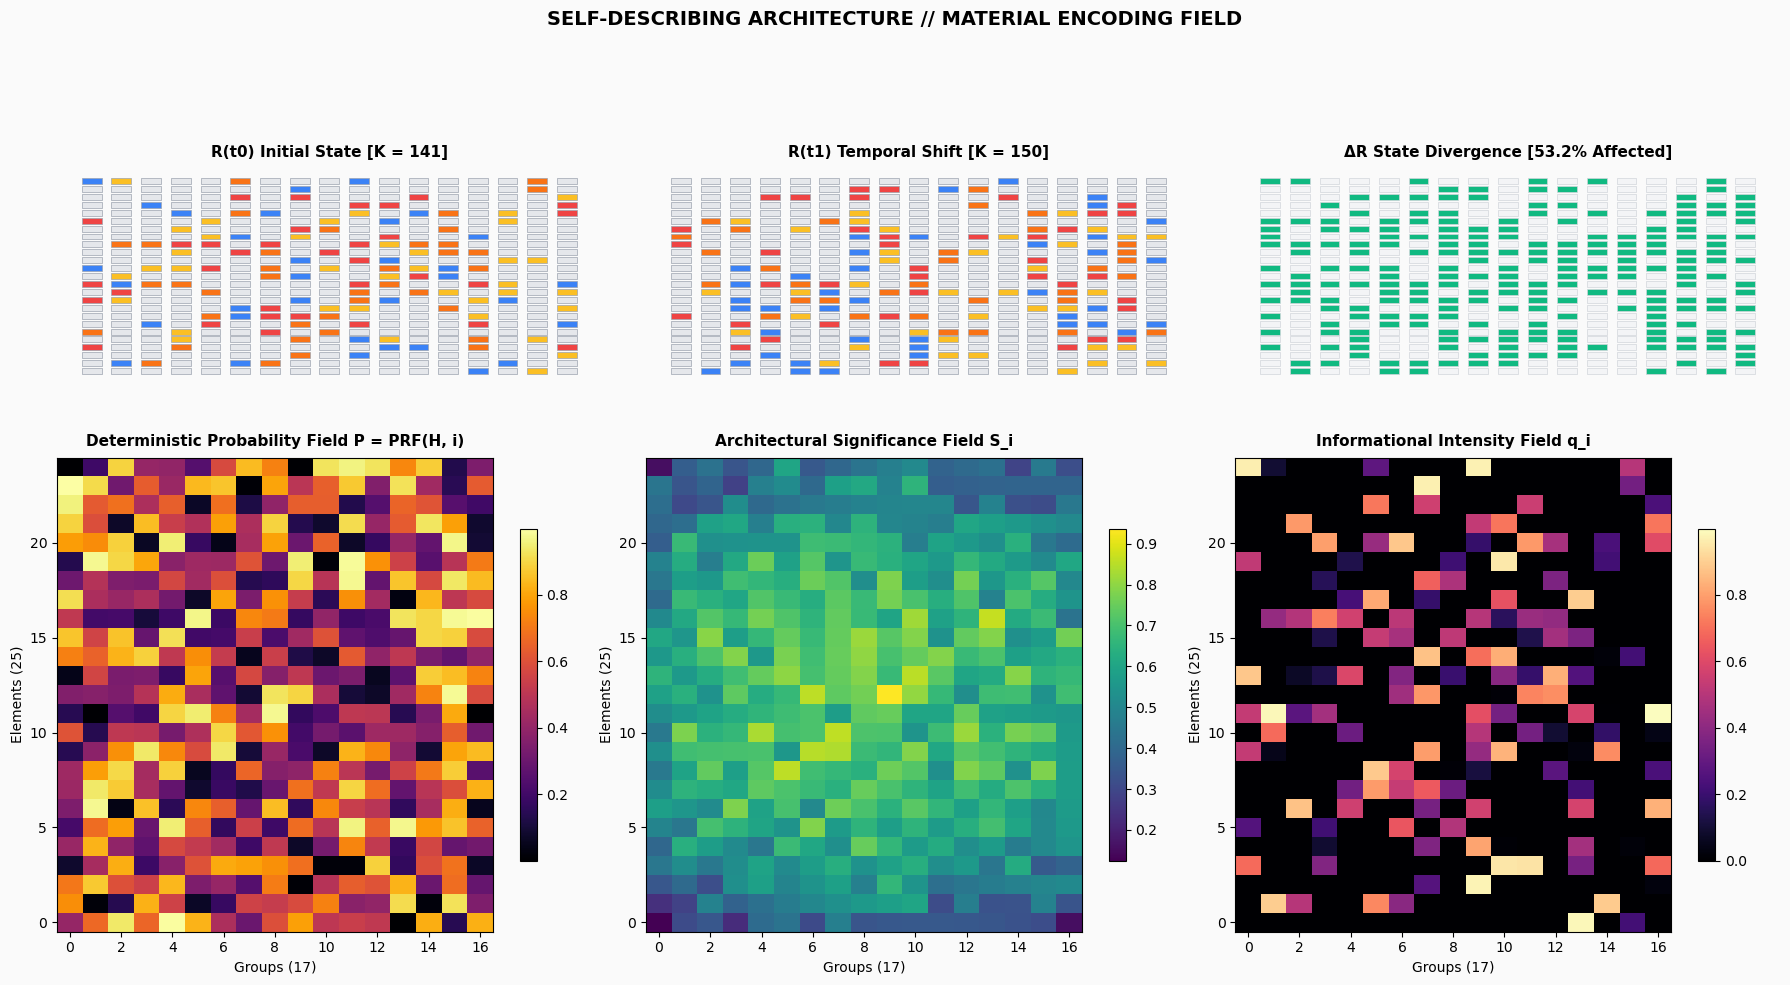

In [5]:
import hashlib
import json
import math
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Any
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# =============================================================================
# DATASTRUCTURES & DOMAIN MODEL
# =============================================================================

@dataclass
class ArchitecturalElement:
    id: int
    grid_x: int  # Group index (0..16)
    grid_y: int  # Position within group (0..24)
    position: Tuple[float, float]
    group_id: int
    material: str
    structural_importance: float
    connectivity: float
    provenance_score: float
    history_score: float
    novelty_score: float
    
    # Emergent / Evaluated fields
    probability: float = 0.0
    significance: float = 0.0
    threshold: float = 0.0
    active: bool = False
    intensity: float = 0.0
    state: int = -1  # -1: Inactive, 0: Yellow, 1: Orange, 2: Red, 3: Blue
    payload: Dict[str, Any] = field(default_factory=dict)


@dataclass
class RoofGroup:
    group_id: int
    element_ids: List[int] = field(default_factory=list)


@dataclass
class RoofState:
    timestamp: str
    building_data: Dict[str, Any]
    canonical_repr: str
    hash_hex: str
    hash_bin: str
    global_info: float
    elements: List[ArchitecturalElement]
    groups: List[RoofGroup]
    
    # Summary Metrics
    emergent_k: int = 0
    differentiated_ratio: float = 0.0
    shannon_entropy: float = 0.0
    normalized_entropy: float = 0.0
    state_frequencies: Dict[int, int] = field(default_factory=dict)
    capacities_bits: Dict[str, float] = field(default_factory=dict)


# =============================================================================
# CORE COMPUTATIONAL PIPELINE
# =============================================================================

def canonicalize_building_data(data: Dict[str, Any]) -> str:
    """Produces a deterministic JSON string with lexicographically sorted keys."""
    return json.dumps(data, sort_keys=True, separators=(',', ':'), ensure_ascii=True)


def calculate_building_hash(canonical_str: str) -> Tuple[str, str]:
    """Generates SHA-256 hash in Hexadecimal and 256-bit Binary formats."""
    digest = hashlib.sha256(canonical_str.encode('utf-8')).digest()
    hex_repr = digest.hex()
    bin_repr = ''.join(f'{byte:08b}' for byte in digest)
    return hex_repr, bin_repr


def calculate_global_information(canonical_str: str) -> float:
    """Calculates normalized byte-level Shannon entropy of the building data string."""
    if not canonical_str:
        return 0.0
    byte_counts: Dict[int, int] = {}
    for b in canonical_str.encode('utf-8'):
        byte_counts[b] = byte_counts.get(b, 0) + 1
    
    total_bytes = len(canonical_str)
    entropy = 0.0
    for count in byte_counts.values():
        p = count / total_bytes
        entropy -= p * math.log2(p)
    
    # Normalized against theoretical max entropy for 8-bit byte stream (8 bits)
    return min(1.0, entropy / 8.0)


def create_probability_field(hash_hex: str, n_elements: int) -> List[float]:
    """Derives a deterministic probability field P = {p_0 ... p_N-1} using PRF."""
    probabilities = []
    for i in range(n_elements):
        seed_str = f"{hash_hex}:{i}"
        digest = hashlib.sha256(seed_str.encode('utf-8')).hexdigest()
        # Take first 8 hex chars (32-bit unsigned int) and map to [0, 1)
        val = int(digest[:8], 16) / float(0xFFFFFFFF)
        probabilities.append(val)
    return probabilities


def calculate_element_significance(
    grid_x: int, grid_y: int, max_x: int = 17, max_y: int = 25,
    weights: Tuple[float, float, float, float, float] = (0.3, 0.25, 0.15, 0.15, 0.15)
) -> Tuple[float, float, float, float, float, float]:
    """
    Computes architectural significance S_i from spatial and topological proxies.
    
    Returns (S_i, structural, connectivity, provenance, history, novelty).
    """
    alpha, beta, gamma, delta, epsilon = weights
    
    # Structural Importance: Peak load at mid-span along Y, moderate along X
    norm_y = grid_y / (max_y - 1)
    struct_imp = 1.0 - 4.0 * (norm_y - 0.5) ** 2  # Parabolic curve peaking at mid-span
    
    # Connectivity: Proximity to group centers/edges
    norm_x = grid_x / (max_x - 1)
    conn_imp = 0.5 + 0.5 * math.sin(norm_x * math.pi)
    
    # Synthetic proxies for provenance, history, novelty based on grid location
    prov_imp = (grid_x * 7 + grid_y * 13) % 10 / 10.0
    hist_imp = (grid_x * 3 + grid_y * 17) % 8 / 8.0
    nov_imp = (grid_x * grid_y) % 11 / 11.0
    
    s_i = (alpha * struct_imp +
           beta * conn_imp +
           gamma * prov_imp +
           delta * hist_imp +
           epsilon * nov_imp)
    
    return s_i, struct_imp, conn_imp, prov_imp, hist_imp, nov_imp


def assign_information_state(intensity: float, entropy_target: float = 0.5) -> int:
    """
    Maps continuous intensity q_i in (0, 1] to discrete physical states {0, 1, 2, 3}.
    Entropy target skews decision boundaries across the four states.
    """
    # Adjust thresholds based on target entropy parameter
    skew = (entropy_target - 0.5) * 0.2
    t1 = max(0.05, 0.25 + skew)
    t2 = max(t1 + 0.05, 0.50)
    t3 = min(0.95, 0.75 - skew)
    
    if intensity < t1:
        return 0  # Yellow
    elif intensity < t2:
        return 1  # Orange
    elif intensity < t3:
        return 2  # Red
    else:
        return 3  # Blue


def calculate_entropy(states: List[int]) -> Tuple[float, float, Dict[int, int]]:
    """Calculates Shannon Entropy and Normalized Entropy for active element states."""
    active_states = [s for s in states if s >= 0]
    if not active_states:
        return 0.0, 0.0, {0: 0, 1: 0, 2: 0, 3: 0}
    
    counts = {s: 0 for s in range(4)}
    for s in active_states:
        counts[s] = counts.get(s, 0) + 1
    
    n = len(active_states)
    shannon = 0.0
    for s in range(4):
        p = counts[s] / n
        if p > 0:
            shannon -= p * math.log2(p)
            
    max_entropy = math.log2(4)  # 2.0 bits
    norm_entropy = shannon / max_entropy
    return shannon, norm_entropy, counts


def build_roof_state(
    building_data: Dict[str, Any],
    timestamp: str = "t0",
    entropy_target: float = 0.5,
    n_groups: int = 17,
    elements_per_group: int = 25
) -> RoofState:
    """Constructs complete RoofState from input metadata."""
    n_total = n_groups * elements_per_group
    
    canonical = canonicalize_building_data(building_data)
    h_hex, h_bin = calculate_building_hash(canonical)
    global_info = calculate_global_information(canonical)
    prob_field = create_probability_field(h_hex, n_total)
    
    elements: List[ArchitecturalElement] = []
    groups: List[RoofGroup] = [RoofGroup(group_id=g) for g in range(n_groups)]
    
    active_count = 0
    states_list = []
    
    for i in range(n_total):
        gx = i // elements_per_group
        gy = i % elements_per_group
        
        s_i, struct, conn, prov, hist, nov = calculate_element_significance(gx, gy, n_groups, elements_per_group)
        p_i = prob_field[i]
        
        threshold = global_info * s_i
        is_active = p_i < threshold
        
        intensity = 0.0
        state = -1
        
        if is_active:
            active_count += 1
            intensity = (threshold - p_i) / threshold
            state = assign_information_state(intensity, entropy_target)
            
        states_list.append(state)
        
        elem = ArchitecturalElement(
            id=i,
            grid_x=gx,
            grid_y=gy,
            position=(float(gx), float(gy)),
            group_id=gx,
            material=building_data["roof"]["material"],
            structural_importance=struct,
            connectivity=conn,
            provenance_score=prov,
            history_score=hist,
            novelty_score=nov,
            probability=p_i,
            significance=s_i,
            threshold=threshold,
            active=is_active,
            intensity=intensity,
            state=state
        )
        elements.append(elem)
        groups[gx].element_ids.append(i)
        
    shannon, norm_ent, counts = calculate_entropy(states_list)
    
    # Capacity calculations (Bits)
    capacities = {
        "active_emergent_4_state": active_count * math.log2(4),
        "total_425_2_state": n_total * math.log2(2),
        "total_425_4_state": n_total * math.log2(4),
        "total_425_8_state": n_total * math.log2(8),
        "total_425_16_state": n_total * math.log2(16),
    }
    
    return RoofState(
        timestamp=timestamp,
        building_data=building_data,
        canonical_repr=canonical,
        hash_hex=h_hex,
        hash_bin=h_bin,
        global_info=global_info,
        elements=elements,
        groups=groups,
        emergent_k=active_count,
        differentiated_ratio=active_count / float(n_total),
        shannon_entropy=shannon,
        normalized_entropy=norm_ent,
        state_frequencies=counts,
        capacities_bits=capacities
    )


def compare_roof_states(r0: RoofState, r1: RoofState) -> Dict[str, Any]:
    """Quantifies structural and informational divergence between two states."""
    n = len(r0.elements)
    activation_changes = 0
    state_changes = 0
    hamming_dist = 0
    
    for e0, e1 in zip(r0.elements, r1.elements):
        if e0.active != e1.active:
            activation_changes += 1
        if e0.state != e1.state:
            state_changes += 1
            hamming_dist += 1
            
    return {
        "activation_changes": activation_changes,
        "state_changes": state_changes,
        "hamming_distance": hamming_dist,
        "percent_affected": (hamming_dist / float(n)) * 100.0
    }


# =============================================================================
# VISUALIZATION SUITE (MATPLOTLIB)
# =============================================================================

def render_architectural_diagrams(r0: RoofState, r1: RoofState, diff: Dict[str, Any]) -> None:
    """Draws multi-panel minimal architectural diagram of the roof field."""
    color_map = {
        -1: "#E5E7EB",  # Inactive: Light Gray
         0: "#FBBF24",  # Yellow
         1: "#F97316",  # Orange
         2: "#EF4444",  # Red
         3: "#3B82F6"   # Blue
    }
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor="#FAFAFA")
    fig.suptitle("SELF-DESCRIBING ARCHITECTURE // MATERIAL ENCODING FIELD", fontsize=14, fontweight="bold", y=0.98)
    
    def plot_roof_grid(ax, roof: RoofState, title: str):
        ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
        ax.set_aspect('equal')
        ax.axis('off')
        
        for elem in roof.elements:
            c = color_map[elem.state]
            # Draw timber elements as thin vertical rectangles
            rect = patches.Rectangle(
                (elem.grid_x * 1.5, elem.grid_y * 0.4), 1.0, 0.3,
                linewidth=0.5, edgecolor="#9CA3AF", facecolor=c
            )
            ax.add_patch(rect)
        ax.autoscale_view()

    # Panel A: R(t0)
    plot_roof_grid(axes[0, 0], r0, f"R(t0) Initial State [K = {r0.emergent_k}]")
    
    # Panel B: R(t1)
    plot_roof_grid(axes[0, 1], r1, f"R(t1) Temporal Shift [K = {r1.emergent_k}]")
    
    # Panel C: Delta Field ΔR
    ax_diff = axes[0, 2]
    ax_diff.set_title(f"ΔR State Divergence [{diff['percent_affected']:.1f}% Affected]", fontsize=11, fontweight="bold", pad=8)
    ax_diff.set_aspect('equal')
    ax_diff.axis('off')
    for e0, e1 in zip(r0.elements, r1.elements):
        c = "#10B981" if e0.state != e1.state else "#F3F4F6"  # Emerald green for changed
        rect = patches.Rectangle(
            (e0.grid_x * 1.5, e0.grid_y * 0.4), 1.0, 0.3,
            linewidth=0.5, edgecolor="#D1D5DB", facecolor=c
        )
        ax_diff.add_patch(rect)
    ax_diff.autoscale_view()
    
    # Panel D: Probability Field Heatmap P
    ax_p = axes[1, 0]
    ax_p.set_title("Deterministic Probability Field P = PRF(H, i)", fontsize=11, fontweight="bold", pad=8)
    p_matrix = np.array([e.probability for e in r0.elements]).reshape(17, 25).T
    im_p = ax_p.imshow(p_matrix, cmap="inferno", origin="lower", aspect="auto")
    fig.colorbar(im_p, ax=ax_p, shrink=0.7)
    ax_p.set_xlabel("Groups (17)")
    ax_p.set_ylabel("Elements (25)")
    
    # Panel E: Significance Field Heatmap S
    ax_s = axes[1, 1]
    ax_s.set_title("Architectural Significance Field S_i", fontsize=11, fontweight="bold", pad=8)
    s_matrix = np.array([e.significance for e in r0.elements]).reshape(17, 25).T
    im_s = ax_s.imshow(s_matrix, cmap="viridis", origin="lower", aspect="auto")
    fig.colorbar(im_s, ax=ax_s, shrink=0.7)
    ax_s.set_xlabel("Groups (17)")
    ax_s.set_ylabel("Elements (25)")

    # Panel F: Active Intensity Map q_i
    ax_q = axes[1, 2]
    ax_q.set_title("Informational Intensity Field q_i", fontsize=11, fontweight="bold", pad=8)
    q_matrix = np.array([e.intensity for e in r0.elements]).reshape(17, 25).T
    im_q = ax_q.imshow(q_matrix, cmap="magma", origin="lower", aspect="auto")
    fig.colorbar(im_q, ax=ax_q, shrink=0.7)
    ax_q.set_xlabel("Groups (17)")
    ax_q.set_ylabel("Elements (25)")

    plt.tight_layout()
    plt.show()


# =============================================================================
# MAIN EXECUTION & ANALYTICAL OUTPUT
# =============================================================================

def main():
    building_data_t0 = {
        "project": "AlgoTecture House 01",
        "location": "Zurich",
        "construction_year": 2027,
        "architect": "AlgoTecture",
        "roof": {
            "type": "timber roof",
            "material": "spruce",
            "element_count": 425,
            "structural_system": "parallel timber members"
        },
        "provenance": {
            "forest": "Graubünden",
            "fabricator": "Fabricator A"
        },
        "history": [
            {"year": 2027, "event": "construction"}
        ]
    }
    
    # Generate Temporal State R(t1) by appending one architectural fact
    building_data_t1 = json.loads(json.dumps(building_data_t0))
    building_data_t1["history"].append({"year": 2052, "event": "beam replacement"})
    building_data_t1["provenance"]["fabricator"] = "Fabricator B"

    # Evaluate states
    r0 = build_roof_state(building_data_t0, timestamp="t0")
    r1 = build_roof_state(building_data_t1, timestamp="t1")
    diff = compare_roof_states(r0, r1)

    # Print Analytical Report
    print("============================================================")
    print("SELF-DESCRIBING ARCHITECTURE")
    print("Architectural Material Encoding Experiment")
    print("============================================================\n")
    
    print("Architectural state:")
    print("--------------------")
    print(f"Elements: {len(r0.elements)}")
    print(f"Groups: {len(r0.groups)}")
    print(f"Elements/group: {len(r0.groups[0].element_ids)}\n")

    print("Cryptographic identity R(t0):")
    print("-----------------------")
    print(f"SHA-256: {r0.hash_hex}")
    print(f"Binary Prefix: {r0.hash_bin[:32]}...\n")

    print("Information:")
    print("------------")
    print(f"Global information measure I(D): {r0.global_info:.6f}")
    print("Method used: Normalized Byte-Level Shannon Entropy of Canonical JSON\n")

    print("Emergent architecture R(t0):")
    print("----------------------")
    print(f"Differentiated elements K: {r0.emergent_k}")
    print(f"Differentiated ratio (K/N): {r0.differentiated_ratio:.4f} ({r0.differentiated_ratio*100:.2f}%)")
    mean_sig = sum(e.significance for e in r0.elements) / len(r0.elements)
    active_elems = [e for e in r0.elements if e.active]
    mean_int = (sum(e.intensity for e in active_elems) / len(active_elems)) if active_elems else 0.0
    print(f"Mean significance S_i: {mean_sig:.4f}")
    print(f"Mean informational intensity q_i: {mean_int:.4f}\n")

    print("Information states R(t0):")
    print("-------------------")
    print(f"Yellow (State 0): {r0.state_frequencies[0]}")
    print(f"Orange (State 1): {r0.state_frequencies[1]}")
    print(f"Red    (State 2): {r0.state_frequencies[2]}")
    print(f"Blue   (State 3): {r0.state_frequencies[3]}\n")

    print("Entropy:")
    print("--------")
    print(f"Shannon entropy H(X): {r0.shannon_entropy:.4f} bits")
    print("Maximum entropy H_max: 2.0000 bits")
    print(f"Normalized entropy: {r0.normalized_entropy:.4f}\n")

    print("Capacity:")
    print("---------")
    print(f"Current active set capacity: {r0.capacities_bits['active_emergent_4_state']:.2f} bits")
    print(f"425-element capacity (2 states): {r0.capacities_bits['total_425_2_state']:.2f} bits")
    print(f"425-element capacity (4 states): {r0.capacities_bits['total_425_4_state']:.2f} bits")
    print(f"425-element capacity (8 states): {r0.capacities_bits['total_425_8_state']:.2f} bits")
    print(f"425-element capacity (16 states): {r0.capacities_bits['total_425_16_state']:.2f} bits\n")

    print("Temporal comparison R(t0) -> R(t1):")
    print("------------------------------------")
    print(f"Activation status changes: {diff['activation_changes']}")
    print(f"State value changes: {diff['state_changes']}")
    print(f"Hamming distance: {diff['hamming_distance']}")
    print(f"Roof area affected: {diff['percent_affected']:.2f}%\n")
    
    # Render Graphics
    render_architectural_diagrams(r0, r1, diff)


# =============================================================================
# FUTURE EXTENSION STUBS / TODO
# =============================================================================
"""
TODO: Future Architectural Information Extensions

1. Graph Topology: Derive structural significance S_i directly from structural finite element (FEM) stiffness matrices and dual-graph centrality measures.
2. Semantic Metrics: Replace JSON string byte-entropy with semantic BIM/IFC ontology metrics (e.g., node depth, graph edit distance).
3. Reed-Solomon Erasure Coding: Implement genuine systematic erasure coding over GF(2^8) across physical element fields.
4. Physical Fabrication Mapping: Map discrete states to CNC milling paths, notch profiles, joint keying, or surface roughness rather than optical colors.
5. Append-Only Memory Ledger: Model history as localized spatial micro-encodings (e.g., ring growth keying) rather than regenerating global hashes.
6. Computer Vision Decoder: Write an OpenCV pipeline that reads physical member states back into a verified IFC building model.
"""

if __name__ == "__main__":
    main()

In [ ]:

from __future__ import annotations

import copy
import hashlib
import json
import math
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ============================================================
# SELF-DESCRIBING ARCHITECTURE / ARCHITECTURAL MATERIAL ENCODING
# Prototype 0.1
#
# Fundamental invariant:
#   N = 425 is an INPUT architectural constraint.
#   K = number of differentiated elements is an OUTPUT.
#
# No uncontrolled randomness is used.
# ============================================================

N_ELEMENTS = 425
N_GROUPS = 5
ELEMENTS_PER_GROUP = 85
GRID_ROWS = 5
GRID_COLS = 85

STATE_NAMES = {0: "yellow", 1: "red", 2: "red", 3: "blue"}
STATE_COLORS = {
    None: "#e6e6e6",
    0: "#f2d64b",
    1: "#cf3d3d",
    2: "#cf3d3d",
    3: "#3769b0",
}

DEFAULT_SIGNIFICANCE_WEIGHTS = {
    "structural": 0.30,
    "connectivity": 0.25,
    "provenance": 0.15,
    "history": 0.15,
    "novelty": 0.15,
}

DEFAULT_INFORMATION_WEIGHTS = {
    "serialization_proxy": 0.25,
    "material": 0.15,
    "topology": 0.25,
    "history": 0.20,
    "provenance": 0.15,
}


@dataclass
class ArchitecturalElement:
    id: int
    x: int
    y: int
    group: int
    material: str

    # Latent informational dimensions.
    structural_importance: float = 0.0
    connectivity: float = 0.0
    provenance: float = 0.0
    history: float = 0.0
    novelty: float = 0.0

    probability: float = 0.0
    significance: float = 0.0
    threshold: float = 0.0
    active: bool = False
    encoded_state: Optional[int] = None
    intensity: float = 0.0
    color: str = STATE_COLORS[None]
    payload: Optional[Dict[str, Any]] = None


@dataclass
class ArchitecturalGroup:
    id: int
    element_ids: List[int] = field(default_factory=list)
    # Placeholder for future group hash / Merkle node / assembly metadata.
    metadata: Dict[str, Any] = field(default_factory=dict)


@dataclass
class InformationMeasure:
    value: float
    components: Dict[str, float]
    weights: Dict[str, float]
    method: str


@dataclass
class RoofState:
    time_label: str
    building_data: Dict[str, Any]
    canonical_data: str
    hash_hex: str
    hash_binary: str
    information: InformationMeasure
    groups: List[ArchitecturalGroup]
    elements: List[ArchitecturalElement]
    entropy_target: float
    entropy_bits: float
    entropy_normalized: float
    state_counts: Dict[int, int]

    @property
    def active_count(self) -> int:
        return sum(e.active for e in self.elements)

    @property
    def active_ratio(self) -> float:
        return self.active_count / len(self.elements)


@dataclass
class TemporalComparison:
    activation_changes: int
    state_changes: int
    representation_hamming_distance: int
    roof_affected_count: int
    roof_affected_ratio: float


# ------------------------------------------------------------
# Canonical representation and cryptographic identity
# ------------------------------------------------------------

def canonicalize_building_data(data: Dict[str, Any]) -> str:
    """
    Deterministic JSON canonicalization for Prototype 0.1.

    Guarantees used here:
      - dictionary key ordering does not matter;
      - insignificant whitespace does not matter;
      - UTF-8 characters are preserved.

    Limitation:
      This is not a complete semantic canonicalization system. For example,
      list order remains meaningful and "2027" != 2027. A future prototype
      should define an architectural schema and semantic normalization rules.
    """
    return json.dumps(
        data,
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=False,
        allow_nan=False,
    )


def calculate_building_hash(canonical_data: str) -> Tuple[str, str]:
    digest = hashlib.sha256(canonical_data.encode("utf-8")).digest()
    return digest.hex(), "".join(f"{byte:08b}" for byte in digest)


def deterministic_unit_interval(seed_hex: str, namespace: str, identifier: str) -> float:
    """
    Hash-based deterministic pseudo-random function (PRF-like construction).

    This creates stochastic-looking, reproducible values. It is NOT evidence
    that semantic information has been encoded or is recoverable.
    """
    message = f"{namespace}|{seed_hex}|{identifier}".encode("utf-8")
    digest = hashlib.sha256(message).digest()
    integer = int.from_bytes(digest[:8], "big")
    return integer / 2**64


# ------------------------------------------------------------
# Information / complexity proxies
# ------------------------------------------------------------

def shannon_entropy_bytes(data: bytes) -> float:
    if not data:
        return 0.0
    counts = Counter(data)
    n = len(data)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())


def normalized_serialization_entropy(canonical_data: str) -> float:
    """
    Preliminary computational proxy only.

    Byte entropy is divided by 8 bits/byte. This measures symbol diversity in
    the serialized representation, NOT architectural complexity.
    """
    return shannon_entropy_bytes(canonical_data.encode("utf-8")) / 8.0


def normalized_diversity(values: List[Any]) -> float:
    if len(values) <= 1:
        return 0.0
    unique = len(set(values))
    # Saturating diversity proxy: 1 unique -> 0; more unique -> approaches 1.
    return 1.0 - 1.0 / unique


def calculate_global_information(
    building_data: Dict[str, Any],
    canonical_data: str,
    weights: Dict[str, float] = DEFAULT_INFORMATION_WEIGHTS,
) -> InformationMeasure:
    """
    Prototype composite I(D) in [0,1].

    Some components are architecture-adjacent; others remain heuristics.
    The explicit decomposition prevents JSON entropy from masquerading as a
    complete architectural complexity metric.
    """
    if not math.isclose(sum(weights.values()), 1.0, abs_tol=1e-9):
        raise ValueError("Information weights must sum to 1.")

    roof = building_data.get("roof", {})
    history = building_data.get("history", [])
    provenance = building_data.get("provenance", {})

    serialization_proxy = normalized_serialization_entropy(canonical_data)

    material_values = [roof.get("material", "unknown")]
    if "secondary_materials" in roof:
        material_values.extend(roof["secondary_materials"])
    material = normalized_diversity(material_values)

    # Heuristic topology/hierarchy proxy.
    hierarchy_depth = 4  # BUILDING -> ROOF -> GROUP -> ELEMENT
    relationship_density_proxy = min(
        1.0,
        (N_ELEMENTS - N_GROUPS + hierarchy_depth) / N_ELEMENTS
    )
    topology = 0.5 * (hierarchy_depth / 6.0) + 0.5 * relationship_density_proxy

    # Saturating count proxies, intentionally transparent and replaceable.
    history_component = 1.0 - math.exp(-len(history) / 3.0)
    provenance_component = 1.0 - math.exp(-len(provenance) / 3.0)

    components = {
        "serialization_proxy": serialization_proxy,
        "material": material,
        "topology": topology,
        "history": history_component,
        "provenance": provenance_component,
    }
    value = sum(weights[k] * components[k] for k in weights)
    value = max(0.0, min(1.0, value))

    return InformationMeasure(
        value=value,
        components=components,
        weights=dict(weights),
        method=(
            "Prototype composite proxy: normalized serialized-byte entropy + "
            "material diversity + hierarchy/topology proxy + saturating "
            "history/provenance counts. Not a validated architectural metric."
        ),
    )


# ------------------------------------------------------------
# Architectural hierarchy and element significance
# ------------------------------------------------------------

def create_groups() -> List[ArchitecturalGroup]:
    return [
        ArchitecturalGroup(
            id=g + 1,
            element_ids=list(
                range(g * ELEMENTS_PER_GROUP + 1, (g + 1) * ELEMENTS_PER_GROUP + 1)
            ),
        )
        for g in range(N_GROUPS)
    ]


def normalized_grid_coordinates(element_id: int) -> Tuple[int, int, float, float]:
    idx = element_id - 1
    y = idx // GRID_COLS
    x = idx % GRID_COLS
    xn = x / (GRID_COLS - 1)
    yn = y / (GRID_ROWS - 1)
    return x, y, xn, yn


def calculate_element_significance(
    element_id: int,
    building_hash: str,
    weights: Dict[str, float] = DEFAULT_SIGNIFICANCE_WEIGHTS,
) -> Tuple[float, Dict[str, float]]:
    """
    Prototype significance S_i.

    REAL-ish architectural property:
      connectivity: derived from grid adjacency.

    SIMPLIFIED architectural heuristic:
      structural_importance: edge/center position proxy.

    PLACEHOLDER deterministic values:
      provenance, history, novelty: hash-derived values until actual per-element
      material passport / event / provenance data exists.
    """
    if not math.isclose(sum(weights.values()), 1.0, abs_tol=1e-9):
        raise ValueError("Significance weights must sum to 1.")

    x, y, xn, yn = normalized_grid_coordinates(element_id)

    # Simplified structural proxy: central members are assigned greater weight.
    center_distance = math.sqrt((xn - 0.5) ** 2 + (yn - 0.5) ** 2) / math.sqrt(0.5)
    structural = max(0.0, 1.0 - center_distance)

    # Actual graph-derived quantity for the simple 4-neighbour grid topology.
    neighbours = 4
    if x in (0, GRID_COLS - 1):
        neighbours -= 1
    if y in (0, GRID_ROWS - 1):
        neighbours -= 1
    connectivity = neighbours / 4.0

    # Deterministic placeholders, clearly not architectural analysis.
    provenance = deterministic_unit_interval(building_hash, "provenance", str(element_id))
    history = deterministic_unit_interval(building_hash, "history", str(element_id))
    novelty = deterministic_unit_interval(building_hash, "novelty", str(element_id))

    components = {
        "structural": structural,
        "connectivity": connectivity,
        "provenance": provenance,
        "history": history,
        "novelty": novelty,
    }
    significance = sum(weights[k] * components[k] for k in weights)
    return max(0.0, min(1.0, significance)), components


def calculate_activation_threshold(global_information: float, significance: float) -> float:
    # Core emergent activation law requested in the research brief.
    return max(0.0, min(1.0, global_information * significance))


def create_probability_field(building_hash: str) -> List[float]:
    return [
        deterministic_unit_interval(building_hash, "activation_probability", str(i))
        for i in range(1, N_ELEMENTS + 1)
    ]


# ------------------------------------------------------------
# Entropy-controlled state distribution
# ------------------------------------------------------------

def entropy_profile(entropy_target: float, n_states: int = 4) -> List[float]:
    """
    Converts entropy_target into a monotonic family of categorical profiles.

    target=0 -> [1,0,0,0]
    target=1 -> [1/4,1/4,1/4,1/4]

    This does NOT control K. It only affects state assignment among active
    elements. It is heuristic and does not solve exact entropy optimization.
    """
    t = max(0.0, min(1.0, entropy_target))
    dominant = 1.0 - t * (1.0 - 1.0 / n_states)
    remainder = (1.0 - dominant) / (n_states - 1)
    return [dominant] + [remainder] * (n_states - 1)


def categorical_from_unit_interval(u: float, probabilities: List[float]) -> int:
    cumulative = 0.0
    for state, p in enumerate(probabilities):
        cumulative += p
        if u < cumulative:
            return state
    return len(probabilities) - 1


def calculate_intensity(probability: float, threshold: float) -> float:
    """
    0 at threshold, 1 for a probability of 0 under a positive threshold.
    """
    if threshold <= 0.0 or probability >= threshold:
        return 0.0
    return max(0.0, min(1.0, (threshold - probability) / threshold))


def determine_emergent_states(
    building_data: Dict[str, Any],
    building_hash: str,
    information: InformationMeasure,
    entropy_target: float,
) -> List[ArchitecturalElement]:
    probabilities = create_probability_field(building_hash)
    state_profile = entropy_profile(entropy_target)

    elements: List[ArchitecturalElement] = []
    material = building_data["roof"]["material"]

    for element_id, p_i in enumerate(probabilities, start=1):
        x, y, _, _ = normalized_grid_coordinates(element_id)
        group = y + 1

        significance, sig_components = calculate_element_significance(
            element_id, building_hash
        )
        threshold = calculate_activation_threshold(information.value, significance)
        active = p_i < threshold
        intensity = calculate_intensity(p_i, threshold)

        encoded_state = None
        color = STATE_COLORS[None]
        payload = {
            "significance_components": sig_components,
            "carrier_independent": True,
        }

        if active:
            # Separate deterministic channel for categorical state.
            u_state = deterministic_unit_interval(
                building_hash, "encoded_state", str(element_id)
            )
            encoded_state = categorical_from_unit_interval(u_state, state_profile)
            color = STATE_COLORS[encoded_state]

        elements.append(
            ArchitecturalElement(
                id=element_id,
                x=x,
                y=y,
                group=group,
                material=material,
                structural_importance=sig_components["structural"],
                connectivity=sig_components["connectivity"],
                provenance=sig_components["provenance"],
                history=sig_components["history"],
                novelty=sig_components["novelty"],
                probability=p_i,
                significance=significance,
                threshold=threshold,
                active=active,
                encoded_state=encoded_state,
                intensity=intensity,
                color=color,
                payload=payload,
            )
        )
    return elements


# ------------------------------------------------------------
# Entropy and capacity
# ------------------------------------------------------------

def calculate_entropy(elements: List[ArchitecturalElement]) -> Tuple[Dict[int, int], float, float]:
    """
    Shannon entropy among ACTIVE encoded states only.

    Inactive is intentionally excluded because the requested four-state
    entropy concerns the differentiated information-state distribution.
    A five-state whole-roof entropy can be added separately if desired.
    """
    active_states = [e.encoded_state for e in elements if e.active]
    counts = Counter(active_states)
    total = len(active_states)

    state_counts = {s: counts.get(s, 0) for s in range(4)}
    if total == 0:
        return state_counts, 0.0, 0.0

    entropy = -sum(
        (count / total) * math.log2(count / total)
        for count in state_counts.values()
        if count > 0
    )
    max_entropy = math.log2(4)
    return state_counts, entropy, entropy / max_entropy


def calculate_information_capacity(n_elements: int, n_states: int) -> float:
    return n_elements * math.log2(n_states)


# ------------------------------------------------------------
# State creation and temporal comparison
# ------------------------------------------------------------

def create_roof_state(
    building_data: Dict[str, Any],
    time_label: str,
    entropy_target: float = 0.85,
) -> RoofState:
    if building_data["roof"]["element_count"] != N_ELEMENTS:
        raise ValueError(f"Prototype requires exactly {N_ELEMENTS} elements.")

    canonical = canonicalize_building_data(building_data)
    hash_hex, hash_binary = calculate_building_hash(canonical)
    information = calculate_global_information(building_data, canonical)
    groups = create_groups()
    elements = determine_emergent_states(
        building_data, hash_hex, information, entropy_target
    )
    counts, entropy_bits, entropy_norm = calculate_entropy(elements)

    return RoofState(
        time_label=time_label,
        building_data=copy.deepcopy(building_data),
        canonical_data=canonical,
        hash_hex=hash_hex,
        hash_binary=hash_binary,
        information=information,
        groups=groups,
        elements=elements,
        entropy_target=entropy_target,
        entropy_bits=entropy_bits,
        entropy_normalized=entropy_norm,
        state_counts=counts,
    )


def element_symbol(e: ArchitecturalElement) -> int:
    """
    Whole-roof discrete representation:
      0 = inactive
      1..4 = active states yellow..blue
    """
    return 0 if not e.active else e.encoded_state + 1


def compare_roof_states(a: RoofState, b: RoofState) -> TemporalComparison:
    if len(a.elements) != len(b.elements):
        raise ValueError("Roof states must contain the same number of elements.")

    activation_changes = sum(x.active != y.active for x, y in zip(a.elements, b.elements))

    # State change counts include active/inactive transitions and active color changes.
    state_changes = sum(element_symbol(x) != element_symbol(y) for x, y in zip(a.elements, b.elements))

    # Hamming distance over the 425-symbol physical representation.
    hamming = state_changes

    affected = sum(
        (
            x.active != y.active
            or x.encoded_state != y.encoded_state
            or not math.isclose(x.intensity, y.intensity, abs_tol=1e-12)
        )
        for x, y in zip(a.elements, b.elements)
    )

    return TemporalComparison(
        activation_changes=activation_changes,
        state_changes=state_changes,
        representation_hamming_distance=hamming,
        roof_affected_count=affected,
        roof_affected_ratio=affected / len(a.elements),
    )


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def _setup_architectural_axes(ax, title: str) -> None:
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_aspect("equal")
    ax.set_xlim(-0.5, GRID_COLS - 0.5)
    ax.set_ylim(GRID_ROWS - 0.25, -0.75)
    ax.axis("off")


def visualize_roof(state: RoofState, output_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(13, 7))
    _setup_architectural_axes(
        ax,
        f"{state.time_label}  |  K={state.active_count}/{N_ELEMENTS}  "
        f"({100*state.active_ratio:.1f}%)"
    )

    member_width = 0.30
    member_height = 0.82
    for e in state.elements:
        # Intensity is represented by alpha, but categorical state remains color.
        alpha = 0.30 + 0.70 * e.intensity if e.active else 1.0
        ax.add_patch(
            Rectangle(
                (e.x - member_width / 2, e.y - member_height / 2),
                member_width,
                member_height,
                facecolor=e.color,
                edgecolor="none",
                alpha=alpha,
            )
        )

    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)


def visualize_difference(a: RoofState, b: RoofState, output_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(13, 7))
    _setup_architectural_axes(ax, f"ΔR  |  {a.time_label} → {b.time_label}")

    member_width = 0.30
    member_height = 0.82
    for x, y in zip(a.elements, b.elements):
        changed = element_symbol(x) != element_symbol(y) or not math.isclose(
            x.intensity, y.intensity, abs_tol=1e-12
        )
        face = "#222222" if changed else "#ededed"
        ax.add_patch(
            Rectangle(
                (x.x - member_width / 2, x.y - member_height / 2),
                member_width,
                member_height,
                facecolor=face,
                edgecolor="none",
            )
        )

    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)


def visualize_scalar_field(
    state: RoofState,
    attribute: str,
    title: str,
    output_path: Path,
) -> None:
    fig, ax = plt.subplots(figsize=(13, 7))
    _setup_architectural_axes(ax, title)

    values = [float(getattr(e, attribute)) for e in state.elements]
    vmin, vmax = min(values), max(values)
    denom = max(vmax - vmin, 1e-12)

    member_width = 0.30
    member_height = 0.82
    cmap = plt.get_cmap("viridis")

    for e, value in zip(state.elements, values):
        normalized = (value - vmin) / denom
        ax.add_patch(
            Rectangle(
                (e.x - member_width / 2, e.y - member_height / 2),
                member_width,
                member_height,
                facecolor=cmap(normalized),
                edgecolor="none",
            )
        )

    # Minimal field scale.
    sm = plt.cm.ScalarMappable(cmap=cmap)
    sm.set_clim(vmin, vmax)
    fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)


# ------------------------------------------------------------
# Reporting
# ------------------------------------------------------------

def print_state_report(state: RoofState) -> None:
    mean_significance = sum(e.significance for e in state.elements) / len(state.elements)
    active_intensities = [e.intensity for e in state.elements if e.active]
    mean_intensity = (
        sum(active_intensities) / len(active_intensities)
        if active_intensities else 0.0
    )

    print("\nSELF-DESCRIBING ARCHITECTURE")
    print("Architectural Material Encoding Experiment")
    print(f"\nSTATE: {state.time_label}")

    print("\nArchitectural state:")
    print("--------------------")
    print(f"Elements: {len(state.elements)}")
    print(f"Groups: {len(state.groups)}")
    print(f"Elements/group: {ELEMENTS_PER_GROUP}")

    print("\nCryptographic identity:")
    print("-----------------------")
    print(f"SHA-256: {state.hash_hex}")
    print(f"Binary: {state.hash_binary}")

    print("\nInformation:")
    print("------------")
    print(f"Global information measure I(D): {state.information.value:.6f}")
    print(f"Method used: {state.information.method}")
    for name, value in state.information.components.items():
        print(f"  {name}: {value:.6f}")

    print("\nEmergent architecture:")
    print("----------------------")
    print(f"Differentiated elements K: {state.active_count}  <-- OUTPUT, not input")
    print(f"Differentiated ratio: {state.active_ratio:.6f}")
    print(f"Differentiated percentage: {100*state.active_ratio:.2f}%")
    print(f"Mean significance: {mean_significance:.6f}")
    print(f"Mean informational intensity (active): {mean_intensity:.6f}")

    print("\nInformation states:")
    print("-------------------")
    for s in range(4):
        print(f"{STATE_NAMES[s].title()}: {state.state_counts[s]}")

    print("\nEntropy:")
    print("--------")
    print(f"Entropy target parameter: {state.entropy_target:.3f}")
    print(f"Shannon entropy (active four-state distribution): {state.entropy_bits:.6f} bits")
    print("Maximum entropy: 2.000000 bits")
    print(f"Normalized entropy: {state.entropy_normalized:.6f}")

    print("\nCapacity:")
    print("---------")
    print(
        "Current differentiated capacity (4 states): "
        f"{calculate_information_capacity(state.active_count, 4):.1f} bits"
    )
    for m in (2, 4, 8, 16):
        print(
            f"425-element capacity with {m} states: "
            f"{calculate_information_capacity(N_ELEMENTS, m):.1f} bits"
        )


def print_temporal_report(comparison: TemporalComparison) -> None:
    print("\nTemporal comparison:")
    print("--------------------")
    print(f"Activation changes: {comparison.activation_changes}")
    print(f"State changes: {comparison.state_changes}")
    print(f"Hamming distance: {comparison.representation_hamming_distance}")
    print(
        f"Roof affected: {comparison.roof_affected_count}/{N_ELEMENTS} "
        f"({100*comparison.roof_affected_ratio:.2f}%)"
    )


def main() -> None:
    building_data = {
        "project": "AlgoTecture House 01",
        "location": "Zurich",
        "construction_year": 2027,
        "architect": "AlgoTecture",
        "roof": {
            "type": "timber roof",
            "material": "spruce",
            "element_count": 425,
            "structural_system": "parallel timber members",
        },
        "provenance": {
            "forest": "Graubünden",
            "fabricator": "Fabricator A",
        },
        "history": [
            {
                "year": 2027,
                "event": "construction",
            }
        ],
    }

    # INPUT design/distribution parameter. It affects state mixture, NOT K.
    entropy_target = 0.85

    # SPACE ENSEMBLE at t0.
    t0 = create_roof_state(building_data, "R(t0)", entropy_target)

    # TIME ENSEMBLE: one meaningful architectural fact changes.
    building_data_t1 = copy.deepcopy(building_data)
    building_data_t1["history"].append(
        {"year": 2052, "event": "beam replacement"}
    )

    t1 = create_roof_state(building_data_t1, "R(t1)", entropy_target)
    comparison = compare_roof_states(t0, t1)

    print_state_report(t0)
    print_state_report(t1)
    print_temporal_report(comparison)

    output_dir = Path("self_describing_architecture_output")
    output_dir.mkdir(exist_ok=True)

    visualize_roof(t0, output_dir / "roof_t0.png")
    visualize_roof(t1, output_dir / "roof_t1.png")
    visualize_difference(t0, t1, output_dir / "roof_delta.png")
    visualize_scalar_field(
        t0, "probability", "Deterministic probability field pᵢ",
        output_dir / "probability_field.png"
    )
    visualize_scalar_field(
        t0, "significance", "Informational significance Sᵢ",
        output_dir / "significance_field.png"
    )
    visualize_scalar_field(
        t0, "threshold", "Activation threshold I(D)·Sᵢ",
        output_dir / "threshold_field.png"
    )

    print(f"\nVisualizations written to: {output_dir.resolve()}")

    # ========================================================
    # RESEARCH LIMITATION:
    # Prototype 0.1 regenerates a global pattern after a data change.
    # A true architectural memory system should become append-only and
    # localize/inherit records rather than globally repainting matter.
    # ========================================================

    # TODO: graph-derived structural significance
    # TODO: real topological connectivity from structural/IFC graph
    # TODO: semantic architectural information metrics
    # TODO: Reed-Solomon coding
    # TODO: erasure coding
    # TODO: recovery from missing elements
    # TODO: distributed redundancy
    # TODO: Merkle trees
    # TODO: hierarchical hashes
    # TODO: local element identity
    # TODO: partial-building authentication
    # TODO: computer-vision decoding
    # TODO: IFC GUIDs
    # TODO: material passports
    # TODO: material provenance
    # TODO: append-only architectural history
    # TODO: physical fabrication constraints
    # TODO: robustness against replacement/damage
    # TODO: recovery experiments


if __name__ == "__main__":
    main()
